### ☀️ 참고 ☀️ 한글깨짐 방지

- 아래 코드셀 3개 실행 필수
- 윈도우, 맥 동일

❗️주의❗️
- Step1. 첫째 셀 실행
- Step2. '런타임 > 세션 다시시작'
- Step3. 이후 두번째 셀 실행

In [1]:
%%capture
# 폰트 및 패키지 설치 (2~3분 소요)

# 1. 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. RAG 충돌 가능 패키지 제거
%pip uninstall -q -y langgraph langgraph-sdk langgraph-prebuilt gradio

# 3. RAG 관련 패키지 버전 고정 설치
%pip install -q \
    "requests==2.32.4" \
    "opentelemetry-api==1.42.1" \
    "opentelemetry-sdk==1.42.1" \
    "opentelemetry-exporter-otlp-proto-grpc==1.42.1" \
    "sentence-transformers==5.6.1" \
    "faiss-cpu==1.14.3" \
    "chromadb==1.5.9" \
    "transformers==4.57.6" \
    "sentencepiece==0.2.2" \
    "langchain==0.3.30" \
    "langchain-community==0.3.27" \
    "langchain-text-splitters==0.3.11" \
    "langchain-huggingface==0.3.1"


print("설치 완료: [런타임] > [세션 다시 시작]")

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl


# 나눔고딕 폰트 사용 설정 (폰트 설치 후 실행)
plt.rcParams["font.family"]="NanumGothic"

# 마이너스 깨짐 방지 (일반 하이픈(-)을 사용하게 설정)
mpl.rcParams['axes.unicode_minus'] = False

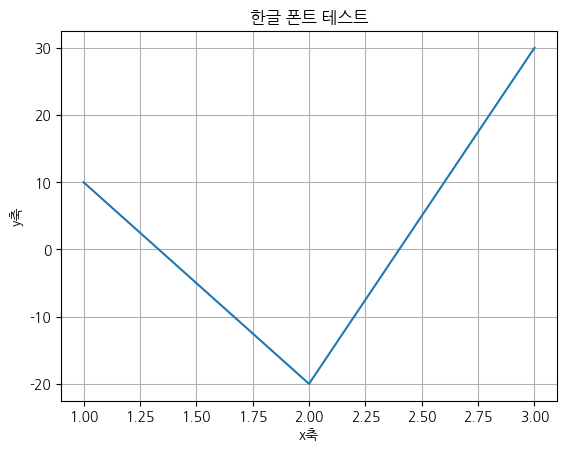

In [2]:
# 한글 폰트 테스트 그래프

plt.plot([1, 2, 3], [10, -20, 30])
plt.title('한글 폰트 테스트')
plt.xlabel('x축')
plt.ylabel('y축')
plt.grid(True)
plt.show()

# 📘 CH18. RAG — 강의용 노트북

01. 30분 만의 첫 RAG · 02. 해부실 ① 검색 엔진 · 03. 해부실 ② 벡터 창고(FAISS) · 04. 프로젝트 — 사내 챗봇 "무지봇" 출시 · 05. 실무 마감 — LangChain 재조립과 최종 대결

> 🔄 **개정 안내**: 이 노트북은 "실험실" 방식으로 진행됩니다.
> - **원리·수식 설명은 개념 교안(장표)이 담당**하고, 이 노트북에서는 **1교시에 실제 동작하는 RAG를 먼저 완성**한 뒤, 2~3교시에 그 부품(검색기·저장소)을 **직접 부숴보면서** 왜 필요한지 몸으로 확인합니다.
> - 스토리: CH17의 말맛컴퍼니 프롬프트 엔지니어, **입사 2주차**. 두 번째 고객사 **무지개상사**의 의뢰 — *"우리 회사 챗봇이 정작 우리 회사를 모릅니다. 고쳐 주세요."*
> - 4교시엔 **여러분이 만든 사내 챗봇 "무지봇"에게 직접 질문을 던지는** 프로젝트, 5교시엔 직접 조립 vs LangChain 최종 대결이 기다립니다.
> - TODO 실습과 실습 과제는 정규 수업이 아닌 **수업 후 자습 시간**에 진행합니다.
> - 💰 **유료 API 전혀 없음**: 임베딩(sentence-transformers)과 LLM(google/flan-t5-base) 모두 무료 로컬 모델입니다. API 키·결제 정보가 전혀 필요 없습니다.
> - ⚠️ **수업 전 준비 필수**: 바로 아래 "설치·모델 다운로드" 셀 2개는 최초 1회 **수 분**이 걸립니다(모델 파일 다운로드). **수업 시작 전에 미리 실행**해두세요. 데이터 파일은 노트북 안에서 직접 생성하므로 별도 배포 파일이 없습니다.
> - 🖥️ 라이브 데모와 🎁 보너스는 진도 상황에 따라 건너뛸 수 있는 독립 구성입니다.

### ⚠️ 수업 전 준비 — 설치 & 모델 다운로드 (최초 1회, 수 분 소요)

아래 두 셀은 라이브러리 설치와 모델 파일 다운로드(임베딩 모델 약 470MB + LLM 약 1GB)를 진행합니다. **수업 시작 전에 미리 실행**해두면 수업 중에는 기다림 없이 진행됩니다.

In [3]:
# 모델 다운로드
# 5분 소요

import torch
from sentence_transformers import SentenceTransformer
from transformers import pipeline

# ① 임베딩 모델 — 한국어를 포함한 50여 개 언어를 지원하는 무료 모델 (약 470MB)
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# ② 생성 모델 - Qwen (알리바바(Alibaba)가 출시한 경량형 오픈소스 대형 언어 모델(LLM))
#generator = pipeline("text2text-generation", model="google/flan-t5-base")
generator = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct", device=0 if torch.cuda.is_available() else -1)


print("준비 완료! 두 모델이 모두 로드되었습니다.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


준비 완료! 두 모델이 모두 로드되었습니다.


---

# 📘 CH18-01. 첫 RAG 만들기 — 챗봇에게 "우리 회사"를 가르치기

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 사건 재현(환각 목격) → RAG 아이디어(오픈북 시험) → 검색기 v0.1 조립 → 프롬프트 결합 → 첫 RAG 완성 → RAG 없이 vs RAG 비교
> 🔧 **실습파일**: 불필요 (문서를 노트북 안에서 직접 생성 — API 키·유료 서비스 전혀 없음)
> ⏱️ **예상 소요시간**: 40분
> 🎚️ **난이도**: ★★★☆☆
> 🔗 **사전 지식**: CH17(LLM·프롬프트 엔지니어링)

---

## 🤔 먼저 생각해보기

> **입사 2주차 월요일 아침, 팀장이 새 의뢰서를 건넵니다 — "두 번째 고객사입니다. 무지개상사라고, IT 스타트업이에요. 사장님 컴플레인이 이렇습니다: '사내 챗봇에게 신입사원이 리모트 근무 되냐고 물었더니 엉뚱한 답을 하더라. ChatGPT는 세상 모든 걸 아는 것 같던데, 왜 우리 회사 일은 하나도 모르냐.' — 금요일까지 고쳐드리기로 했습니다."**

당연한 결과입니다. LLM은 **학습할 때 본 적 없는 정보**(우리 회사 규정, 오늘 아침 뉴스, 여러분의 개인 문서)는 알 수가 없고, 더 무섭게는 **모르면서도 그럴듯하게 지어냅니다(환각)**. 오늘의 미션은 이 문제를 푸는 기술 — **RAG(Retrieval-Augmented Generation, 검색 증강 생성)** 입니다. 이론부터 3일 배우지 않습니다. **지금부터 30분 안에 동작하는 RAG를 먼저 완성**하고, 오후 내내 그 부품을 하나씩 뜯어봅니다.

---

## 📖 만들기

### 1) 사건 재현 — 환각을 눈으로 목격하기

사장님이 목격한 그 장면부터 재현합니다. CH17의 무료 LLM(flan-t5-base)에게 회사 질문을 그대로 던져봅니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 참고 자료 없이 LLM에게 바로 회사 질문 던지기

question = "무지개상사의 리모트 근무 정책은 무엇인가요?"

messages = [
    {
        "role": "user",
        "content": f"다음 질문에 한국어로 간단히 답하세요.\n\n질문: {question}"
    }
]

result = generator(
    messages,
    max_new_tokens=100,
    do_sample=False
)

answer = result[0]["generated_text"][-1]["content"]

print("질문:", question)
print("LLM의 답변:", answer)
```

</details>

In [4]:
# 참고 자료 없이 LLM에게 바로 회사 질문 던지기

question = "무지개상사의 리모트 근무 정책은 무엇인가요?"

messages = [{"role": "user", "content": f"다음 질문에 한국어로 간단히 답하세요.\n\n질문: {question}"}]

# do_sample = False (무작위 생성 줄임)
# max_new_tokens = (답변 토큰 수 제한)
# return_full_text = False (입력 프롬프트 제외, 생성된 답변만 출력)
result = generator(messages, max_new_tokens = 100, do_sample = False)
answer = result[0]['generated_text'][-1]['content']

print("질문:", question)
print("LLM의 답변:", answer)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


질문: 무지개상사의 리모트 근무 정책은 무엇인가요?
LLM의 답변: 무지개상사는 리모트 근무를 지원하는 정책은 없습니다. 이는 상황에 따라 달라집니다. 일반적으로, 리모트 근무는 직원이 원활하게 일하고 싶을 때만 권장됩니다. 그러나 특정 상황에서 필요한 경우에도, 해당 사항을 확인하여 적절한 방법을 선택해야 합니다.


> 💡 LLM은 "무지개상사"라는 회사의 문서를 학습한 적이 전혀 없습니다. 그런데도 "모릅니다"라고 하는 대신 **뭔가를 지어내는 경우**가 있습니다 — 이것이 **환각(Hallucination)** 이고, 실제 서비스에서 가장 위험한 사고 유형입니다.

### 2) 해결 아이디어 — 오픈북 시험

| 구분 | 순수 LLM | RAG |
|---|---|---|
| 시험 방식 | 암기한 것만으로 답안 작성 | **참고서를 펼쳐놓고** 답안 작성 |
| 모르는 문제 | 지어낼 위험 (환각) | 참고서에서 찾아 근거 있는 답 |
| 최신·사내 정보 | 불가능 | 참고서(문서)만 갈아끼우면 됨 |

RAG의 전체 흐름은 딱 3단계입니다:

```
사용자 질문
    ↓
① 관련 문서 검색 (Retrieval) — "참고서에서 관련 페이지 찾기"
    ↓
② 찾은 문서 + 질문을 함께 LLM에 전달 (Augmented) — "참고 자료를 문제지에 붙이기"
    ↓
③ LLM이 문서를 참고해 답변 생성 (Generation) — "근거를 보고 답안 작성"
```

### 3) 참고서 준비 — 무지개상사 미니 지식베이스

먼저 챗봇이 펼쳐볼 "참고서"를 만듭니다. 지금은 문서 6개짜리 미니 버전입니다 (진짜 핸드북은 4교시 프로젝트에서).

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 무지개상사 사내 문서 (미니 버전) — 챗봇이 펼쳐볼 "참고서"
documents = [
    "무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다.",
    "무지개상사의 점심시간은 12시부터 1시까지입니다.",
    "무지개상사의 창립일은 2020년 3월 15일입니다.",
    "무지개상사는 매주 금요일 오후 2시에 전체 회의를 진행합니다.",
    "무지개상사의 본사는 서울 강남구에 위치해 있습니다.",
    "무지개상사 사내 카페 구름다방에서는 아메리카노를 500원에 판매합니다.",
]
print(f"참고서 준비 완료: 문서 {len(documents)}개")
```

</details>

In [5]:
# 무지개상사 사내 문서 (미니 버전) — 챗봇이 펼쳐볼 "참고서"

documents = [
    "무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다.",
    "무지개상사의 점심시간은 12시부터 1시까지입니다.",
    "무지개상사의 창립일은 2020년 3월 15일입니다.",
    "무지개상사는 매주 금요일 오후 2시에 전체 회의를 진행합니다.",
    "무지개상사의 본사는 서울 강남구에 위치해 있습니다.",
    "무지개상사 사내 카페 구름다방에서는 아메리카노를 500원에 판매합니다.",
]

print(f"참고서 준비 완료: 문서 {len(documents)}개")

참고서 준비 완료: 문서 6개


### 4) 검색기 v0.1 조립 — 일단 가장 단순하게

①번 단계(검색)를 만듭니다. 가장 단순한 아이디어부터: **질문과 겹치는 단어가 가장 많은 문서**를 고르는 겁니다. (이 검색기의 운명은... 2교시에 밝혀집니다.)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 검색기 v0.1 — 단어 겹침 검색: 질문과 겹치는 단어가 가장 많은 문서를 고른다
def word_overlap_search(question, documents):
    question_words = set(question.split())
    best_doc, best_score = None, -1
    for doc in documents:
        score = len(question_words & set(doc.split()))   # 겹치는 단어 개수
        if score > best_score:
            best_score = score
            best_doc = doc
    return best_doc

question = "무지개상사의 리모트 근무 정책은 무엇인가요?"
retrieved_doc = word_overlap_search(question, documents)
print("검색된 문서:", retrieved_doc)
```

</details>

In [6]:
# 검색기 v0.1
# 단어 겹침 검색: 질문과 겹치는 단어가 가장 많은 문서를 고른다
# set은 중복제거 + 교집합 계산이 쉬워짐

# ①번 단계(검색)
def word_overlap_search(question, documents):
    question_words = set(question.split())
    best_doc, best_score = None, -1

    for doc in documents:
        score = len(question_words & set(doc.split()))
        if score > best_score:
            best_score = score
            best_doc = doc

    return best_doc

question = "무지개상사의 리모트 근무 정책은 무엇인가요?"
retrieved_doc = word_overlap_search(question, documents)
print("검색된 문서:", retrieved_doc)


검색된 문서: 무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다.


### 5) 프롬프트에 참고 자료 붙이기 — CH17 복습

②번 단계(증강)는 사실 CH17에서 배운 **프롬프트 엔지니어링** 그 자체입니다. 검색된 문서를 "참고 자료"로 붙인 프롬프트를 조립합니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 검색된 문서를 참고 자료로 붙인 프롬프트 조립 (CH17 프롬프트 복습)
prompt = f"""다음 참고 자료를 바탕으로 질문에 답하세요.

참고 자료: {retrieved_doc}

질문: {question}
답변:"""

print(prompt)
```

</details>

In [7]:
# 검색된 문서를 참고 자료로 붙인 프롬프트 조립 (CH17 프롬프트 복습)

# ②번 단계(증강)
messages = [
    {"role": "system","content": "제공된 참고 자료만 사용해 한국어로 답하세요."},
    {"role": "user", "content": f"참고 자료:{retrieved_doc} 질문: {question}"}
]

# result
result = generator(messages, max_new_tokens = 100, do_sample = False)
answer = result[0]["generated_text"][-1]["content"]

print("검색된 문서:", retrieved_doc)
print("RAG 답변:", answer)

검색된 문서: 무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다.
RAG 답변: 무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있습니다. 이를 통해 사무실에서 일하는 직원들이 일정 시간 동안 출근할 수 있게 됩니다. 이는 직원들의 휴식과 일상 생활을 개선하는데 도움이 될 것입니다.


### 6) 답변 생성 — 첫 RAG 완성

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# ③ 생성 — 참고 자료가 붙은 프롬프트로 답변 생성
result = generator(prompt, max_length=100)
print("RAG 답변:", result[0]["generated_text"])
```

</details>

In [8]:
# ③ 생성
# 참고 자료가 붙은 프롬프트로 답변 생성
messages = [
    {"role": "system", "content": "참고 자료만 사용하여 한국어로 답하세요."},
    {"role": "user", "content": f"참고 자료:{retrieved_doc} 질문: {question}"}
]

# result
result = generator(messages, max_new_tokens = 100, do_sample = False)
answer = result[0]["generated_text"][-1]["content"]

print("RAG 답변:", answer)

RAG 답변: 무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있습니다. 이는 사무실에서 일하는 직원들이 일정 시간 동안 출근할 수 있도록 하는 방침입니다. 필요하다면 사무실에 출근할 수 있습니다.


🎉 **완성입니다.** 방금 여러분은 검색(①) → 증강(②) → 생성(③)의 RAG 전체 파이프라인을 직접 조립했습니다. 아까는 지어내던 챗봇이, 이제 **회사 문서를 근거로** 답합니다.

> 💡 소형 모델 안내: Qwen2.5-0.5B-Instruct는 무료 소형 LLM이라 대형 모델(GPT·Claude 등)보다 답변의 정확도와 자연스러움이 부족할 수 있습니다. 오늘 실습의 핵심은 모델 성능이 아니라 RAG의 구조입니다. 생성 모델만 GPT·Claude 같은 대형 LLM으로 교체해도, 검색(Retrieval) → 프롬프트 조립(Augmented Prompt) → 답변 생성(Generation)의 흐름은 그대로 유지됩니다.

### 7) 최종 확인 — RAG 없이 vs RAG 적용

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 같은 질문, 두 가지 방식 정면 비교
# 1분 정도 소요

# [A] RAG 없이
result_no_rag = generator( f"질문: {question}\n답변:", max_new_tokens=100, do_sample=False)

# [B] RAG 적용
result_with_rag = generator(messages, max_new_tokens=100, do_sample=False)

print("[A] RAG 없이 :", result_no_rag[0]["generated_text"])
print()
print("[B] RAG 적용 :", result_with_rag[0]["generated_text"][-1]["content"])
print()
print("참고한 문서 :", retrieved_doc)


# [A] RAG 없이
# → 참고 자료가 없어 LLM이 그럴듯한 내용을 추측하여 생성함 (할루시네이션)
# max_new_tokens = 100 (최대 100토큰이지만 종료를 잘 못하는 경우가 있음)

# [B] RAG 적용
# → 검색된 문서를 참고하여 실제 근거를 바탕으로 답변함 (RAG 성공)
```

</details>

In [9]:
# 같은 질문, 두 가지 방식 정면 비교
# 1분 정도 소요

# [A] RAG 없이
result_no_rag = generator(f"질문: {question} \n답변: ", max_new_tokens = 100, do_sample = False)

# [B] RAG 적용
result_with_rag = generator(messages, max_new_tokens = 100, do_sample = False)

print("[A] RAG 없이 :", result_no_rag[0]["generated_text"])
print()
print("[B] RAG 적용 :", result_with_rag[0]["generated_text"][-1]["content"])
print()
print("참고한 문서 :", retrieved_doc)


# [A] RAG 없이
# → 참고 자료가 없어 LLM이 그럴듯한 내용을 추측하여 생성함 (할루시네이션)
# max_new_tokens = 100 (최대 100토큰이지만 종료를 잘 못하는 경우가 있음)

# [B] RAG 적용
# → 검색된 문서를 참고하여 실제 근거를 바탕으로 답변함 (RAG 성공)

[A] RAG 없이 : 질문: 무지개상사의 리모트 근무 정책은 무엇인가요? 
답변: 1. 무지개상사는 2019년부터 리모트 근무를 시작했습니다. 2. 리모트 근무는 직원들의 일정을 변경하거나, 그들이 원하는 시간에 근무할 수 있도록 도와주는 역할을 합니다. 3. 리모트 근무는 직원들에게 편안하고 안전한 환경을 제공하기 위해 설계되었습니다. 4. 리모

[B] RAG 적용 : 무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있습니다. 이는 사무실에서 일하는 직원들이 일정 시간 동안 출근할 수 있도록 하는 방침입니다. 필요하다면 사무실에 출근할 수 있습니다.

참고한 문서 : 무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다.


| 구분 | 순수 LLM | RAG |
|---|---|---|
| 사내·최신 정보 | ❌ 모름 (지어낼 위험) | ✅ 문서에서 찾아 답변 |
| 답의 근거 | 없음 (블랙박스) | **검색된 문서를 제시 가능** |
| 정보 업데이트 | 모델 재학습 필요 (비용 큼) | 문서만 갈아끼우면 끝 |

그런데 지금 코드에는 수상한 부품이 하나 숨어 있습니다 — **검색기 v0.1(단어 겹침)**. 이게 얼마나 잘 부서지는 물건인지, 2교시에 직접 부숴봅니다.

---

> ✏️ 아래 TODO 실습과 실습 과제는 **수업 후 자습 시간**에 진행합니다.

In [ ]:
# TODO 1 (나만의 참고서): 좋아하는 주제(취미, 동네 맛집, 최애 게임 등)에 대한 문서 3~5개를 문자열 리스트로 만드세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답 (주제는 자유)
my_documents = [
    "제주도는 한라산과 아름다운 해변으로 유명한 대한민국의 섬입니다.",
    "제주도의 대표 음식은 흑돼지구이와 갈치조림입니다.",
    "제주도는 매년 봄 유채꽃 축제로 많은 관광객이 방문합니다.",
]
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 2 (나만의 RAG): TODO 1의 문서로 검색 → 프롬프트 조립 → 생성까지 RAG 3단계를 전부 실행하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 코드 입력

q = "제주도 음식이 뭐야?"
doc = word_overlap_search(q, my_documents)

my_prompt = f"""다음 참고 자료를 바탕으로 질문에 답하세요.

참고 자료: {doc}

질문: {q}
답변:"""

answer = generator(
    my_prompt,
    max_new_tokens=80,
    do_sample=False
)

print("검색된 문서:", doc)
print("답변:", answer[0]["generated_text"])

```

</details>

In [ ]:
# 코드 입력




---

In [ ]:
# 과제 1: 5개 이상의 문서로 나만의 미니 지식베이스를 만들고,
#         서로 다른 질문 3개에 대해 RAG 흐름(검색 → 프롬프트 조립 → 생성)을 전부 실행해보세요

# 과제 2: 같은 질문 하나를 "RAG 없이"와 "RAG 적용"으로 각각 생성해서 답변을 비교하고,
#         어떤 차이가 있었는지 주석으로 한 줄 기록하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
knowledge_base = [
    "파이썬은 1991년 귀도 반 로섬이 만든 프로그래밍 언어입니다.",
    "파이썬은 문법이 간결해서 초보자가 배우기 좋습니다.",
    "파이썬은 데이터 분석, 인공지능 분야에서 널리 사용됩니다.",
    "파이썬의 대표적인 라이브러리로 NumPy와 Pandas가 있습니다.",
    "파이썬 공식 마스코트는 파란색과 노란색 두 마리의 뱀입니다.",
]

questions = ["파이썬은 누가 만들었어?", "파이썬은 어디에 쓰여?", "파이썬 마스코트는?"]
for q in questions:
    doc = word_overlap_search(q, knowledge_base)
    p = f"다음 참고 자료를 바탕으로 질문에 답하세요.\n\n참고 자료: {doc}\n\n질문: {q}\n답변:"
    answer = generator(p, max_length=80)
    print(f"Q: {q}\nA: {answer[0]['generated_text']}\n")
```

</details>

In [ ]:
# 과제 1 예시 정답





<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
test_q = "파이썬은 누가 만들었어?"
no_rag = generator(f"질문: {test_q}\n답변:", max_length=80)
doc = word_overlap_search(test_q, knowledge_base)
with_rag = generator(f"다음 참고 자료를 바탕으로 질문에 답하세요.\n\n참고 자료: {doc}\n\n질문: {test_q}\n답변:", max_length=80)

print("RAG 없이:", no_rag[0]["generated_text"])
print("RAG 적용:", with_rag[0]["generated_text"])
# 관찰 기록: RAG 없이는 지어내거나 엉뚱한 답 / RAG 적용은 문서 근거로 답변
```

</details>

In [ ]:
# 과제 2 예시 정답



# 관찰 기록: RAG 없이는 지어내거나 엉뚱한 답 / RAG 적용은 문서 근거로 답변


---

# 📘 CH18-02. 해부실 ① — 검색 엔진: 단어 겹침을 부수고, 임베딩으로 바꿉니다

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 브라우저 실험(Embedding Projector) → 실험 A: 검색기 v0.1 부수기 → 실험 B: 임베딩 검색 v1.0 → 유사도 지도 → Top-K 검색 → RAG에 새 검색기 장착
> 🔧 **실습파일**: 불필요 (1교시 문서 이어서 사용 — 전부 무료 로컬 모델)
> ⏱️ **예상 소요시간**: 45분
> 🎚️ **난이도**: ★★★★☆
> 📊 **개념 교안**: 임베딩·코사인 유사도의 수식과 원리는 장표에서 다룹니다 — 이 노트북은 "직접 부숴보는 실험"만 합니다.

---

## 🤔 먼저 생각해보기

> **사수의 첫 해부 지시 — "1교시 검색기, 잘 돌아가는 것 같죠? 그럼 이렇게 물어보세요. '다 같이 모이는 시간이 언제야?' — 정답 문서(금요일 전체 회의)와 겹치는 단어가 몇 개인지 세어보시고요."**

세어보면... **0개**입니다. "회의"라는 단어 없이 회의를 물어봤으니까요. 사람은 당연히 알아듣지만, 단어 겹침 검색은 **글자만 보고 의미를 전혀 모릅니다**. 이번 교시의 목표는 검색기를 **"글자를 세는 기계"에서 "의미를 이해하는 기계"로** 교체하는 것 — 그 핵심 부품이 **임베딩(Embedding)** 입니다.

---

## 🖥️ 실험 0 — 브라우저 임베딩 탐험

**🔗 접속**: [Embedding Projector](https://projector.tensorflow.org/) — 설치 없이 브라우저에서 임베딩 공간을 3D로 탐험하는 구글의 도구

**실험 순서 (강사 시연 후 각자 도전)**
1. 접속하면 단어 1만 개(Word2Vec 10K)가 3D 공간에 점으로 떠 있습니다 — **단어 하나하나가 벡터(좌표)가 되어 공간에 배치**된 모습입니다.
2. 오른쪽 검색창에 **coffee** 를 입력하고 클릭 — 이웃(nearest neighbors)에 tea, drink, wine 같은 단어들이 나타납니다. **의미가 비슷한 단어는 공간에서도 가까이** 있습니다.
3. 이번엔 **king** 을 검색 — queen, prince, emperor가 이웃으로 뜹니다. 철자가 아니라 **의미로 뭉쳐 있는** 것을 확인하세요.

**✏️ 자유 체험**: 각자 아무 영어 단어나 검색해서 "이웃"이 납득되는지 확인해보세요. — 방금 눈으로 본 "의미의 지도"를, 이제 우리 검색기에 코드로 장착합니다.

---

## 📖 실험

### 실험 A — 검색기 v0.1 부수기

사수가 시킨 그 질문을 그대로 던집니다. 정답은 "매주 금요일 오후 2시에 전체 회의" 문서여야 합니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 1교시 검색기 v0.1에 "단어가 하나도 안 겹치는" 질문 던지기
tricky_question = "다 같이 모이는 시간이 언제야?"

broken_result = word_overlap_search(tricky_question, documents)
print("질문:", tricky_question)
print("검색기 v0.1의 선택:", broken_result)   # 겹치는 단어가 없어 엉뚱한 문서를 고른다
```

</details>

In [10]:
# 1교시 검색기 v0.1에 "단어가 하나도 안 겹치는" 질문 던지기
tricky_question = '다 같이 모여서 토론하는 시간이 언제야?'

broken_result = word_overlap_search(tricky_question, documents)
print("질문:", tricky_question)
print("검색기 v0.1의 선택:", broken_result)   # 겹치는 단어가 없어 엉뚱한 문서를 고른다


질문: 다 같이 모여서 토론하는 시간이 언제야?
검색기 v0.1의 선택: 무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다.


> 💡 검색이 틀리면 그 뒤는 볼 것도 없습니다 — **엉뚱한 참고 자료로는 LLM도 엉뚱한 답**을 만듭니다(쓰레기가 들어가면 쓰레기가 나온다). RAG의 성패는 사실상 **검색 품질**이 좌우합니다.

### 실험 B — 새 부품 장착: 임베딩

임베딩은 문장을 **의미 좌표(숫자 벡터)** 로 바꿉니다. Embedding Projector에서 본 그 공간을, 이제 한국어 문장으로 직접 만들어봅니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sentence_transformers import SentenceTransformer
import numpy as np

# 한국어를 지원하는 무료 임베딩 모델 (수업 전 준비 셀에서 이미 다운로드됨)
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# 글자는 거의 안 겹치지만 의미는 비슷한 두 문장 + 전혀 다른 문장 하나
sentence1 = "강아지가 마당에서 뛰어놀고 있다"
sentence2 = "개가 정원에서 신나게 뛰어다닌다"
sentence3 = "오늘 주식 시장이 폭락했다"

emb1 = embedding_model.encode(sentence1)
emb2 = embedding_model.encode(sentence2)
emb3 = embedding_model.encode(sentence3)

print("벡터의 모양:", emb1.shape)   # (384,) — 문장 하나가 384차원 좌표가 됨
```

</details>

In [11]:
# 라이브러리 불러오기
from sentence_transformers import SentenceTransformer
import numpy as np

# 한국어를 지원하는 무료 임베딩 모델 (수업 전 준비 셀에서 이미 다운로드됨)
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# 글자는 거의 안 겹치지만 의미는 비슷한 두 문장 + 전혀 다른 문장 하나
sentence1 = '강아지가 마당에서 뛰어놀고 있다'
sentence2 = '개가 정원에서 신나게 뛰어다닌다'
sentence3 = '오늘 주식 시장이 폭락했다'

emb1 = embedding_model.encode(sentence1)
emb2 = embedding_model.encode(sentence2)
emb3 = embedding_model.encode(sentence3)

print("벡터의 모양:", emb1.shape)   # (384,) — 문장 하나가 384차원 좌표가 됨
print(emb1)

벡터의 모양: (384,)
[ 3.70617777e-01  1.96123913e-01 -8.09124187e-02  3.59398872e-02
 -1.70175627e-01 -1.05563916e-01  4.06774551e-01 -9.69367288e-03
  1.42782023e-02  4.82665040e-02  2.43728995e-01 -3.42765808e-01
  1.90605581e-01 -6.72291890e-02  1.03549855e-02  6.78819343e-02
 -3.44576277e-02  1.38349622e-01 -1.37115553e-01 -2.75142998e-01
  6.01099730e-02 -6.87248185e-02  3.73573676e-02  1.82981289e-03
 -1.51300609e-01 -2.37607360e-01 -6.11381941e-02  1.27103701e-01
  3.68930958e-02  1.93169117e-01  2.09297881e-01 -1.08256899e-01
 -7.51561811e-03  9.16470662e-02 -2.61291955e-02  2.47643039e-01
  4.55826409e-02 -2.70899206e-01 -7.07444698e-02  1.56850934e-01
 -5.20357005e-02 -6.66589150e-03  2.04653010e-01  2.30678752e-01
 -1.93246230e-01  2.63314456e-01 -1.61695644e-01 -1.83875680e-01
 -1.06771179e-01 -2.29980245e-01  1.95811793e-01 -6.05760179e-02
 -2.59212941e-01 -7.60629550e-02  2.14134157e-01  2.54592318e-02
  4.26955581e-01  1.76919743e-01 -1.35928094e-01  3.25236380e-01
  3.542898

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 코사인 유사도 — 두 벡터가 같은 방향을 볼수록 1에 가까움 (수식·원리는 개념 교안 참고)
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print(f"강아지/마당  vs 개/정원   : {cosine_similarity(emb1, emb2):.4f}")   # 높음 — 글자가 달라도 의미가 비슷
print(f"강아지/마당  vs 주식 폭락 : {cosine_similarity(emb1, emb3):.4f}")   # 낮음 — 전혀 다른 주제
```

</details>

In [12]:
# 코사인 유사도 — 두 벡터가 같은 방향을 볼수록 1에 가까움 (수식·원리는 개념 교안 참고)

def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print(f"문장1  vs 문장2 : {cosine_similarity(emb1, emb2):.4f}")   # 높음 — 글자가 달라도 의미가 비슷
print(f"문장1  vs 문장3 : {cosine_similarity(emb1, emb3):.4f}")   # 낮음 — 전혀 다른 주제

# 강아지/마당  vs 개/정원   : 0.9441
# 강아지/마당  vs 주식 폭락 : 0.6510

문장1  vs 문장2 : 0.9441
문장1  vs 문장3 : 0.6510


> 💡 "강아지"와 "개", "마당"과 "정원" — **겹치는 글자가 거의 없는데도 유사도가 높게** 나옵니다. 임베딩 모델이 철자가 아닌 **의미**를 비교하고 있다는 증거입니다.

### 검색기 v1.0 — 임베딩 검색으로 교체

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 참고서 전체를 한 번에 임베딩 (1교시 documents 그대로)
doc_embeddings = embedding_model.encode(documents)
print(doc_embeddings.shape)   # (6, 384) — 문서 6개, 각각 384차원 벡터

# 검색기 v1.0 — 질문 벡터와 가장 가까운(유사도가 가장 높은) 문서를 고른다
def embedding_search(question, documents, doc_embeddings, model):
    question_embedding = model.encode(question)
    similarities = [cosine_similarity(question_embedding, d) for d in doc_embeddings]
    best_idx = np.argmax(similarities)
    return documents[best_idx], similarities[best_idx]
```

</details>

In [13]:
# 참고서 전체를 한 번에 임베딩 (1교시 documents 그대로)
doc_embeddings = embedding_model.encode(documents)

print(doc_embeddings.shape)
# (6, 384) — 문서 6개, 각각 384차원 벡터

(6, 384)


In [14]:
# 검색기 v1.0
# 질문 벡터와 가장 가까운(유사도가 가장 높은) 문서를 고른다

def embedding_search(question, documents, doc_embeddings, model):
    question_embedding = model.encode(question)
    similarities = [cosine_similarity(question_embedding, d) for d in doc_embeddings]
    best_idx = np.argmax(similarities)
    return documents[best_idx], similarities[best_idx]


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 실험 A에서 v0.1을 부쉈던 바로 그 질문으로 재대결
best_doc, score = embedding_search(tricky_question, documents, doc_embeddings, embedding_model)

print("질문:", tricky_question)
print(f"검색기 v1.0의 선택: {best_doc} (유사도 {score:.4f})")   # 이번엔 회의 문서를 정확히 찾아낸다
```

</details>

In [15]:
# 실험 A에서 v0.1을 부쉈던 바로 그 질문으로 재대결
best_doc, score = embedding_search(tricky_question, documents, doc_embeddings, embedding_model)

print("질문:", tricky_question)
print(f"검색기 v1.0의 선택: {best_doc} (유사도 {score:.4f})")


질문: 다 같이 모여서 토론하는 시간이 언제야?
검색기 v1.0의 선택: 무지개상사는 매주 금요일 오후 2시에 전체 회의를 진행합니다. (유사도 0.4006)


### 유사도 지도 — 검색기의 머릿속 들여다보기

검색기가 각 질문을 어느 문서와 얼마나 가깝다고 보는지, 한 장의 지도로 확인합니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 질문 3개 × 문서 6개의 유사도를 히트맵으로 시각화

import matplotlib.pyplot as plt

test_questions = ["다 같이 모여서 토론하는 시간이 언제야?", "밥은 언제 먹을 수 있어?", "커피 얼마야?"]

sim_matrix = []
for q in test_questions:
    q_emb = embedding_model.encode(q)
    sim_matrix.append([cosine_similarity(q_emb, d) for d in doc_embeddings])
sim_matrix = np.array(sim_matrix)


plt.figure(figsize=(10, 3.5))
plt.imshow(sim_matrix, cmap="Blues", aspect="auto")
plt.colorbar(label="유사도")
plt.yticks(range(len(test_questions)), test_questions)
plt.xticks(range(len(documents)), [f"문서{i}" for i in range(len(documents))])

for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        plt.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.title("질문 × 문서 유사도 지도 (진할수록 가까움)")
plt.tight_layout()
plt.show()

for i, d in enumerate(documents):
    print(f"문서{i}: {d}")

```

</details>

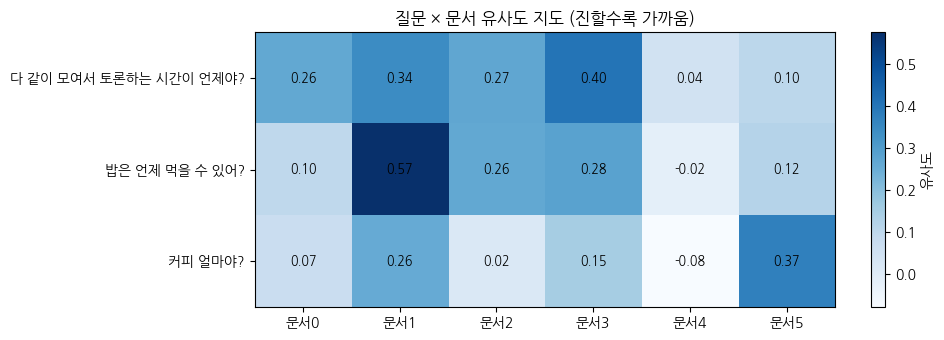

문서0: 무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다.
문서1: 무지개상사의 점심시간은 12시부터 1시까지입니다.
문서2: 무지개상사의 창립일은 2020년 3월 15일입니다.
문서3: 무지개상사는 매주 금요일 오후 2시에 전체 회의를 진행합니다.
문서4: 무지개상사의 본사는 서울 강남구에 위치해 있습니다.
문서5: 무지개상사 사내 카페 구름다방에서는 아메리카노를 500원에 판매합니다.


In [16]:
# 질문 3개 × 문서 6개의 유사도를 히트맵으로 시각화

import matplotlib.pyplot as plt

test_questions = ["다 같이 모여서 토론하는 시간이 언제야?", "밥은 언제 먹을 수 있어?", "커피 얼마야?"]

sim_matrix = []
for q in test_questions:
    q_emb = embedding_model.encode(q)
    sim_matrix.append([cosine_similarity(q_emb, d) for d in doc_embeddings])
sim_matrix = np.array(sim_matrix)


plt.figure(figsize=(10, 3.5))
plt.imshow(sim_matrix, cmap="Blues", aspect="auto")
plt.colorbar(label="유사도")
plt.yticks(range(len(test_questions)), test_questions)
plt.xticks(range(len(documents)), [f"문서{i}" for i in range(len(documents))])

for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        plt.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.title("질문 × 문서 유사도 지도 (진할수록 가까움)")
plt.tight_layout()
plt.show()

for i, d in enumerate(documents):
    print(f"문서{i}: {d}")


> 💡 "밥은 언제 먹을 수 있어?"라는 질문에 **"점심시간" 문서**가, "커피 얼마야?"에 **"구름다방" 문서**가 가장 진하게 표시되나요? 겹치는 단어가 없어도 의미로 연결하는 것 — 이것이 임베딩 검색의 힘입니다.

### Top-K 검색 — 참고 자료를 여러 장 뽑기

실무에서는 1등 문서 하나가 아니라 **상위 K개**를 뽑아 LLM에게 함께 줍니다. 정답이 2등 문서에 있을 수도 있으니까요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
def top_k_search(question, documents, doc_embeddings, model, k=2):
    question_embedding = model.encode(question)
    similarities = [cosine_similarity(question_embedding, d) for d in doc_embeddings]
    top_k_idx = np.argsort(similarities)[::-1][:k]   # 유사도가 높은 순으로 k개
    return [(documents[i], similarities[i]) for i in top_k_idx]

results = top_k_search("무지개상사는 어떤 회사야?", documents, doc_embeddings, embedding_model, k=3)
for doc, score in results:
    print(f"({score:.4f}) {doc}")
```

</details>

In [17]:
# 코드 입력
def top_k_search(question, documents, doc_embeddings, model, k=2):
    question_embedding = model.encode(question)
    similarities = [cosine_similarity(question_embedding, d) for d in doc_embeddings]
    top_k_idx = np.argsort(similarities)[::-1][:k]   # 유사도가 높은 순으로 k개
    return [(documents[i], similarities[i]) for i in top_k_idx]

prompt = "무지개상사는 어떤 회사야?"

# top_k_search
results = top_k_search(prompt, documents, doc_embeddings, embedding_model, k = 3)

for doc, score in results:
    print(f"({score:.4f}) {doc}")


(0.4212) 무지개상사 사내 카페 구름다방에서는 아메리카노를 500원에 판매합니다.
(0.2692) 무지개상사는 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다.
(0.2241) 무지개상사의 본사는 서울 강남구에 위치해 있습니다.


### 새 검색기를 RAG에 장착 — v1.0 출고

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 1교시 RAG의 검색기만 v0.1 → v1.0으로 교체 (나머지 구조는 그대로!)
question = "다 같이 모이는 시간이 언제야?"

best_doc, _ = embedding_search(question, documents, doc_embeddings, embedding_model)
prompt = f"다음 참고 자료를 바탕으로 질문에 답하세요.\n\n참고 자료: {best_doc}\n\n질문: {question}\n답변:"
result = generator(prompt, max_length=100)

print("검색된 문서:", best_doc)
print("RAG v1.0 답변:", result[0]["generated_text"])
```

</details>

In [18]:
# 코드 입력

# 1교시 RAG의 검색기만 v0.1 → v1.0으로 교체 (나머지 구조는 그대로!)

question = "다 같이 모여서 토론하는 시간이 언제야?"

# 원래는 word_overlap_search() 함수
best_doc, _ = embedding_search(question, documents, doc_embeddings, embedding_model)

prompt = f"다음 참고 자료를 바탕으로 질문에 답하세요.\n\n참고 자료: {best_doc}\n\n질문: {question}\n답변:"
result = generator(prompt, max_new_tokens=200)

print("검색된 문서:", best_doc)
print("RAG v1.0 답변:", result[0]["generated_text"])


검색된 문서: 무지개상사는 매주 금요일 오후 2시에 전체 회의를 진행합니다.
RAG v1.0 답변: 다음 참고 자료를 바탕으로 질문에 답하세요.

참고 자료: 무지개상사는 매주 금요일 오후 2시에 전체 회의를 진행합니다.

질문: 다 같이 모여서 토론하는 시간이 언제야?
답변: 무지개상사의 매주 금요일 오후 2시에는 모든 참석자들이 함께 토론을 할 수 있습니다. 따라서 이 시간은 모든 참석자를 포함한 모든 사람들이 참여할 수 있는 시간입니다. 하지만, 개인적인 의견이나 문제 해결 방안 등에 대한 이야기나 논의가 있을 수도 있습니다. 이는 해당 주제에 대해 토론하고자 하는 사람들과 함께 합니다. 따라서 이러한 정보는 일반적으로 모든 참석자가 참여해야 하며, 특정한 시간에만 열리거나 특정한 사람만 참여하도록 조정될 수 없습니다. 따라서, 이 정보는 일반적으로 모든 참석자가 참여해야 할 필요성이 있고, 그들의 의견이나 논의가 이루어지기 위해서는 해당 주제에 대해 토론해야 합니다. 따라서 이 정보는 일반적으로 모든 참석자가 참여해야 할 필요성이 있고, 그들의 의견이나 논의가 이루어지기


| 구분 | 단어 겹침 검색 (v0.1) | 임베딩 검색 (v1.0) |
|---|---|---|
| 비교 기준 | 글자(단어)가 겹치는 개수 | **의미** 벡터 사이의 거리 |
| 동의어·표현 변화 | ❌ "회의" ≠ "다 같이 모임" | ✅ 의미가 같으면 찾아냄 |
| 실무 사용 | 보조 수단 (키워드 검색) | **RAG 검색의 표준** |

검색기는 똑똑해졌습니다. 그런데 사수가 묻습니다 — *"문서가 6개니까 전부 비교해도 되죠. 그런데 우리 회사 문서가 **1만 개**라면?"* — 3교시에서 확인합니다.

---

> ✏️ 아래 TODO 실습과 실습 과제는 **수업 후 자습 시간**에 진행합니다.

In [ ]:
# TODO 1 (검색기 대결): TODO(1교시)에서 만든 나만의 문서에 대해, 단어가 안 겹치는 질문 하나를 만들어
#        word_overlap_search와 embedding_search의 결과를 비교하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답 (1교시 my_documents 사용)
my_embs = embedding_model.encode(my_documents)
q = "그 섬에서 뭘 먹으면 좋아?"   # "음식"이라는 단어 없이 음식을 묻기

print("단어 겹침:", word_overlap_search(q, my_documents))
print("임베딩   :", embedding_search(q, my_documents, my_embs, embedding_model)[0])
```

</details>

In [ ]:
# 코드 입력





In [ ]:
# TODO 2 (Projector 미션): projector.tensorflow.org에서 단어 2개를 검색해보고,
#        각 단어의 이웃(nearest neighbors) 중 인상 깊었던 것을 주석으로 기록하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답 (기록은 사람마다 다를 수 있습니다)
# 검색어 1: "python" → 이웃에 programming, java와 함께 snake도 등장 — 두 의미가 한 공간에!
# 검색어 2: "seoul" → 이웃에 korea, tokyo, beijing — 도시들끼리 뭉쳐 있음
```

</details>

In [ ]:
# 코드 입력
# circuits - 단수형인 circuit이 가장 가까운 이웃임...
# if - 온갖 접속사들이 이웃. 가장 가까운 이웃이 Therefore


---

In [ ]:
# 과제 1: 무지개상사 documents에 대해 "단어를 전혀 다르게 바꾼" 질문 3개를 만들어
#         embedding_search가 전부 정답 문서를 찾는지 확인하세요 (예: "본사 위치" → "회사가 어느 동네에 있어?")

# 과제 2: top_k_search의 k를 1, 3, 6으로 바꿔가며 같은 질문을 검색하고,
#         k가 커질 때 어떤 문서까지 딸려오는지(장점과 부작용)를 주석으로 기록하세요


**예시 정답**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
paraphrased = ["회사가 어느 동네에 있어?", "언제부터 집에서 일할 수 있게 됐어?", "이 회사는 언제 생겼어?"]
for q in paraphrased:
    doc, score = embedding_search(q, documents, doc_embeddings, embedding_model)
    print(f"Q: {q}\n→ ({score:.4f}) {doc}\n")
```

</details>

In [ ]:
# 과제 1 예시 정답




<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
for k in [1, 3, 6]:
    print(f"--- k={k} ---")
    for doc, score in top_k_search("점심은 언제 먹어?", documents, doc_embeddings, embedding_model, k=k):
        print(f"({score:.4f}) {doc}")
# 관찰 기록: k가 커지면 놓칠 위험은 줄지만, 관련 없는 문서까지 참고 자료에 섞여 들어간다
```

</details>

In [ ]:
# 과제 2 예시 정답





# 관찰 기록: k가 커지면 놓칠 위험은 줄지만, 관련 없는 문서까지 참고 자료에 섞여 들어간다


---

# 📘 CH18-03. 해부실 ② — 벡터 창고: 문서 1만 개의 세계 (FAISS)

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 문서 1만 개 스트레스 테스트 → 속도 대결: 반복문 vs FAISS → FAISS 실전 사용법 → ChromaDB 살짝 맛보기 → 비교 정리
> 🔧 **실습파일**: 불필요 (2교시 데이터 이어서 사용 — 전부 무료 로컬 라이브러리)
> ⏱️ **예상 소요시간**: 45분
> 🎚️ **난이도**: ★★★★☆
> 📊 **개념 교안**: 벡터DB·인덱스의 원리는 장표에서 다룹니다 — 이 노트북은 "속도 대결 실험"만 합니다.

---

## 🤔 먼저 생각해보기

> **사수 — "검색기는 합격입니다. 그런데 지금 방식, 질문이 올 때마다 문서 '전부'와 유사도를 하나씩 계산하죠? 우리 회사 위키가 문서 1만 페이지입니다. 고객사는 100만 페이지고요. 반복문 돌려서 언제 다 비교할 겁니까?"**

문서 6개일 때는 티가 안 나지만, 규모가 커지면 **검색 속도**가 서비스의 생명이 됩니다. 수많은 벡터를 창고에 정리해두고 **비슷한 것을 빠르게 꺼내주는 전용 저장소**가 **벡터 데이터베이스(Vector DB)** — 오늘은 그중 가장 널리 쓰이는 무료 오픈소스 **FAISS**를 씁니다.

---

## 📖 실험

### 실험 A — 문서 1만 개 스트레스 테스트 (반복문 검색)

가상의 문서 1만 개(벡터 1만 개)를 만들어, 지금 방식(반복문)이 얼마나 버티는지 잽니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import time

# 가상의 대량 문서 벡터 1만 개 (384차원 — 우리 임베딩과 같은 모양)
np.random.seed(42)
large_embeddings = np.random.rand(10000, 384).astype("float32")
query_vec = np.random.rand(1, 384).astype("float32")

# 방법 A: 반복문으로 하나씩 코사인 유사도 계산 (지금까지의 방식)
start = time.time()
sims = []
for emb in large_embeddings:
    sim = np.dot(emb, query_vec[0]) / (np.linalg.norm(emb) * np.linalg.norm(query_vec[0]))
    sims.append(sim)
best_idx_manual = np.argmax(sims)
manual_time = time.time() - start

print(f"반복문 검색: {manual_time:.4f}초 (질문 1개당)")
```

</details>

In [19]:
import time

# 가상의 대량 문서 벡터 1만 개 (384차원 — 우리 임베딩과 같은 모양)
# 가상의 질문 1개
np.random.seed(42)
large_embeddings = np.random.rand(10000, 384).astype('float32')
query_vec = np.random.rand(1, 384).astype('float32')


### 코사인 유사도

두 벡터의 방향이 얼마나 비슷한지를 계산합니다.

$$
\text{Cosine Similarity}
=
\frac{\mathbf{A} \cdot \mathbf{B}}
{\|\mathbf{A}\| \, \|\mathbf{B}\|}
$$

- $\mathbf{A} \cdot \mathbf{B}$ : 두 벡터의 내적
- $\|\mathbf{A}\|$ : 벡터 A의 길이
- $\|\mathbf{B}\|$ : 벡터 B의 길이

In [20]:
# 방법 A: 반복문으로 하나씩 코사인 유사도 계산 (지금까지의 방식)
# 질문(벡터)와 문서(벡터)를 비교

start = time.time()
sims = []

for emb in large_embeddings:
    sim = np.dot(emb, query_vec[0]) / (np.linalg.norm(emb) * np.linalg.norm(query_vec[0]))
    sims.append(sim)
best_idx_manual = np.argmax(sims)
manual_time = time.time() - start

print(f"반복문 검색: {manual_time:.4f}초 (질문 1개당)")

반복문 검색: 0.0694초 (질문 1개당)


> 💡 "1초도 안 걸리는데요?" — 질문 1개 기준입니다. 동시 접속자 1,000명이 각자 질문하면? 문서가 100만 개라면? 곱해보면 서비스가 버티지 못합니다.

### 실험 B — 속도 대결: FAISS 참전

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 방법 B

import faiss

# 반복문과 같은 "코사인 유사도" 기준으로 공정하게 대결하도록, 벡터 길이를 1로 정규화
# (길이가 1인 벡터끼리의 내적(IP) = 코사인 유사도)
# 즉, 정규화한 벡터끼리는 ㅐ적값이 곧 코사인 유사도 값

# 문서 벡터 정규화 (벡터 길이 1)
large_norm = large_embeddings / np.linalg.norm(large_embeddings, axis=1, keepdims=True)
# 질문 벡터 정규화 (벡터 길이 1)
query_norm = query_vec / np.linalg.norm(query_vec)

# 384차원 벡터를 내적(IP) 기준으로 검색하는 FAISS 검색기 생성
# 검색기 생성 (빈 DB)
large_index = faiss.IndexFlatIP(384)
# 문서 벡터 등록
large_index.add(large_norm)

start = time.time()
# k = 몇개 찾을지 (몇위까지)
similarities, indices = large_index.search(query_norm, k=1)
faiss_time = time.time() - start

print(f"반복문 검색: {manual_time:.4f}초")
print(f"FAISS 검색 : {faiss_time:.4f}초")
print(f"→ FAISS가 약 {manual_time / faiss_time:.0f}배 빠름")

```

</details>

In [21]:
# 방법 B
import faiss

# 반복문과 같은 "코사인 유사도" 기준으로 공정하게 대결하도록, 벡터 길이를 1로 정규화
# (길이가 1인 벡터끼리의 내적(IP) = 코사인 유사도)
# 즉, 정규화한 벡터끼리는 내적값이 곧 코사인 유사도 값

# 문서 벡터 정규화 (벡터 길이 1)
large_norm = large_embeddings / np.linalg.norm(large_embeddings, axis = 1, keepdims = True)

# 질문 벡터 정규화 (벡터 길이 1)
query_norm = query_vec / np.linalg.norm(query_vec)

# 384차원 벡터를 내적(IP) 기준으로 검색하는 FAISS 검색기 생성
# 검색기 생성 (빈 DB)
large_index = faiss.IndexFlatIP(384)

# 문서 벡터 등록
large_index.add(large_norm)

start = time.time()
# k = 몇개 찾을지 (몇위까지)
similarities, indices = large_index.search(query_norm, k=1)
faiss_time = time.time() - start

print(f"반복문 검색: {manual_time:.4f}초")
print(f"FAISS 검색 : {faiss_time:.4f}초")
print(f"→ FAISS가 약 {manual_time / faiss_time:.0f}배 빠름")


반복문 검색: 0.0694초
FAISS 검색 : 0.0073초
→ FAISS가 약 10배 빠름


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 대결 결과를 그래프로
plt.figure(figsize=(7, 3.5))
bars = plt.bar(["반복문 검색", "FAISS 검색"], [manual_time, faiss_time], color=["#cccccc", "#2E4BE8"])
plt.ylabel("검색 시간 (초)")
plt.title(f"문서 1만 개 검색 속도 대결 — FAISS 약 {manual_time / faiss_time:.0f}배 승리")
for bar, t in zip(bars, [manual_time, faiss_time]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{t:.4f}초", ha="center", va="bottom")
plt.tight_layout()
plt.show()
```

</details>

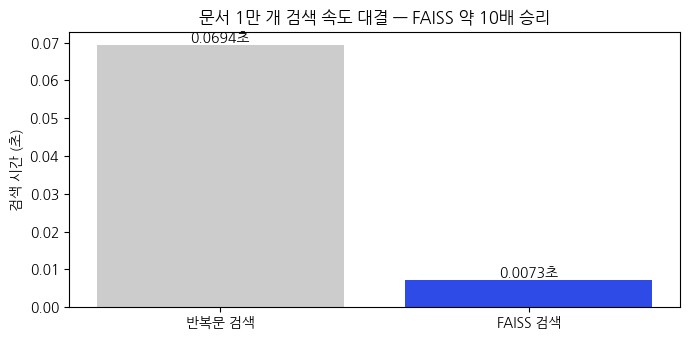

In [22]:
# 코드 입력

# 대결 결과를 그래프로
plt.figure(figsize=(7, 3.5))

bars = plt.bar(["반복문 검색", "FAISS 검색"], [manual_time, faiss_time], color=["#cccccc", "#2E4BE8"])

plt.ylabel("검색 시간 (초)")
plt.title(f"문서 1만 개 검색 속도 대결 — FAISS 약 {manual_time / faiss_time:.0f}배 승리")

for bar, t in zip(bars, [manual_time, faiss_time]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{t:.4f}초", ha="center", va="bottom")

plt.tight_layout()
plt.show()


> 💡 `IndexFlatIP`는 FAISS의 가장 단순한 인덱스 중 하나로, 내부적으로는 모든 벡터와 값을 계산합니다 — 그런데도 고도로 최적화되어 반복문보다 압도적으로 빠릅니다. 데이터가 수백만 개 규모가 되면 근사 검색 인덱스(IVF, HNSW 등)로 더 빨라질 수 있습니다(심화 자습 자료 참고).

### FAISS 실전 — 우리 회사 문서를 창고에 넣기

이제 진짜 우리 문서(무지개상사)를 FAISS 창고에 정리합니다. 순서는 늘 같습니다: **① 정규화해서 임베딩 → ② 창고 만들기·등록 → ③ 검색**. 정규화 덕분에 FAISS 점수가 2교시의 코사인 유사도와 **같은 값·같은 언어**가 됩니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# ① 정규화해서 임베딩 — 벡터 길이를 1로 (정규화 벡터끼리의 내적 = 코사인 유사도)
doc_embeddings_norm = embedding_model.encode(documents, normalize_embeddings=True).astype("float32")

# ② 창고(인덱스) 만들기 + 벡터 등록
dimension = doc_embeddings_norm.shape[1]   # 384
index = faiss.IndexFlatIP(dimension)       # IP(내적) 인덱스
index.add(doc_embeddings_norm)
print(f"창고에 등록된 벡터 개수: {index.ntotal}")
```

</details>

In [23]:
# 코드 입력

# ① 정규화 + 임베딩 동시 — 벡터 길이를 1로 (정규화 벡터끼리의 내적 = 코사인 유사도)
doc_embeddings_norm = embedding_model.encode(documents, normalize_embeddings = True).astype('float32')

# ② 창고(인덱스) 만들기 + 벡터 등록
# 384 얻어내기
dimension = doc_embeddings_norm.shape[1]

# faiss 검색기 만들기 (384차원)
index = faiss.IndexFlatIP(dimension)

# 문서 벡터 등록
index.add(doc_embeddings_norm)
print(f"창고에 등록된 벡터 개수: {index.ntotal}")

창고에 등록된 벡터 개수: 6


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# ③ 검색 — 질문도 똑같이 정규화해서, 가장 가까운 k개를 꺼내기
query = "다 같이 모이는 시간이 언제야?"
query_embedding = embedding_model.encode([query], normalize_embeddings=True).astype("float32")

k = 2
similarities, indices = index.search(query_embedding, k)

print("검색된 문서 인덱스:", indices)
print("유사도(클수록 비슷):", similarities)   # 2교시 코사인 유사도와 같은 값!
for idx in indices[0]:
    print(f"- {documents[idx]}")
```

</details>

In [24]:
# ③ 검색 — 질문도 똑같이 정규화해서, 가장 가까운 k개를 꺼내기
query = "다 같이 모여서 토론하는 시간이 언제야?"
query_embedding = embedding_model.encode([query], normalize_embeddings=True).astype("float32")

k = 2
similarities, indices = index.search(query_embedding, k)

print("검색된 문서 인덱스:", indices)
print("유사도(클수록 비슷):", similarities)   # 2교시 코사인 유사도와 같은 값!

for idx in indices[0]:
    print(f"- {documents[idx]}")

검색된 문서 인덱스: [[3 1]]
유사도(클수록 비슷): [[0.40057936 0.34307522]]
- 무지개상사는 매주 금요일 오후 2시에 전체 회의를 진행합니다.
- 무지개상사의 점심시간은 12시부터 1시까지입니다.


> 💡 정규화 + IP 조합 덕분에 FAISS 점수가 2교시 코사인 유사도와 **같은 값**으로 나옵니다 — 하루 종일 하나의 언어(유사도)로 말할 수 있죠. 참고로 실무에서는 거리 기반(`IndexFlatL2`, 작을수록 비슷)도 널리 쓰입니다 — 점수의 방향만 반대일 뿐 "가장 가까운 문서 찾기"라는 역할은 같습니다. ⚠️ 단, 거리와 유사도는 순위가 항상 일치하지는 않으므로, **정규화 여부와 인덱스 종류를 한 쌍으로** 맞추는 것이 실무 습관입니다.

### 여러 질문을 한 번에 — 배치 검색

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 질문 여러 개를 한 번의 search로 처리 (실무: 동시에 들어오는 사용자 질문들)
queries = ["회사는 어디에 있나요?", "점심은 언제 먹나요?", "커피는 얼마인가요?"]
query_embeddings = embedding_model.encode(queries, normalize_embeddings=True).astype("float32")

similarities, indices = index.search(query_embeddings, k=1)

for query, idx_row in zip(queries, indices):
    print(f"질문: {query}")
    print(f"  → {documents[idx_row[0]]}")
```

</details>

In [25]:
# 질문 여러 개를 한 번의 search로 처리 (실무: 동시에 들어오는 사용자 질문들)
queries = ["회사는 어디에 있나요?", "점심은 언제 먹나요?", "커피는 얼마인가요?"]

query_embeddings = embedding_model.encode(queries, normalize_embeddings=True).astype("float32")

similarities, indices = index.search(query_embeddings, k=1)

for query, idx_row in zip(queries, indices):
    print(f"질문: {query}")
    print(f"  → {documents[idx_row[0]]}")

질문: 회사는 어디에 있나요?
  → 무지개상사 사내 카페 구름다방에서는 아메리카노를 500원에 판매합니다.
질문: 점심은 언제 먹나요?
  → 무지개상사의 점심시간은 12시부터 1시까지입니다.
질문: 커피는 얼마인가요?
  → 무지개상사 사내 카페 구름다방에서는 아메리카노를 500원에 판매합니다.


### ChromaDB 살짝 맛보기 — "임베딩까지 알아서" 해주는 대안

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 코드 입력

import chromadb

# 완전 무료, 로컬에서 동작 (서버·API 키 불필요)
chroma_client = chromadb.Client()

# rainbow_docs라는 이름의 문서 보관함을 가져오거나, 없으면 새로 만듦
collection = chroma_client.get_or_create_collection(name="rainbow_docs")

# 문서 텍스트만 넣으면 임베딩 계산까지 내부에서 자동 처리
# upsert: 같은 id로 다시 넣어도 덮어쓰기 — 셀을 위에서부터 재실행해도 충돌하지 않습니다 (add는 중복 id에서 충돌 가능)
collection.upsert(
    documents=documents,
    ids=[f"doc_{i}" for i in range(len(documents))],
)

results = collection.query(query_texts=["회의는 언제 하나요?"], n_results=2)
print(results["documents"])

```

</details>

In [26]:
# 코드 입력
import chromadb

chroma_client = chromadb.Client()
collection = chroma_client.get_or_create_collection(name = 'rainbow_docs')

collection.upsert(
    documents = documents, ids = [f'doc_{i}' for i in range(len(documents))]
)

results = collection.query(query_texts=["회의는 언제 하나요?"], n_results=2)
print(results["documents"])


/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:24<00:00, 3.37MiB/s]


[['무지개상사의 본사는 서울 강남구에 위치해 있습니다.', '무지개상사는 매주 금요일 오후 2시에 전체 회의를 진행합니다.']]


> 💡 ChromaDB는 문서 텍스트를 넣으면 임베딩까지 자동 처리해주는 "더 간편한" 벡터DB입니다. **FAISS는 속도·세밀한 제어**에, **ChromaDB는 사용 편의성**에 강점이 있습니다. (참고: ChromaDB 내장 기본 임베딩 모델은 영어 중심이라, 한국어 실전에서는 임베딩 모델을 직접 지정해 사용합니다 — 우리는 이후에도 FAISS + 우리 임베딩 모델 조합을 씁니다.)

| 구분 | 반복문(NumPy) 검색 | FAISS | ChromaDB |
|---|---|---|---|
| 속도 (대규모) | ❌ 느림 | ✅ 매우 빠름 | ✅ 빠름 |
| 사용 난이도 | 쉬움 (직접 구현) | 보통 (벡터 직접 관리) | 쉬움 (임베딩 자동) |
| 실무 포지션 | 학습용 | 대규모·성능 중시 | 프로토타입·간편함 중시 |

부품이 다 모였습니다 — 의미를 아는 **검색기(임베딩)**, 대규모를 버티는 **창고(FAISS)**, 답을 만드는 **생성기(LLM)**. 4교시엔 이걸 전부 조립해서, 진짜 회사 핸드북으로 **사내 챗봇을 출시**합니다.

---

> ✏️ 아래 TODO 실습과 실습 과제는 **수업 후 자습 시간**에 진행합니다.

In [ ]:
# TODO 1 (창고 확장): 무지개상사 documents에 새 문서 2개를 추가한 뒤 FAISS 인덱스를 새로 만들고,
#        추가한 문서가 검색되는 질문을 던져 확인하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
new_docs = documents + [
    "무지개상사의 연차는 입사 첫 해 15일이 주어집니다.",
    "무지개상사는 매월 마지막 주 수요일에 생일 파티를 엽니다.",
]
new_embs = embedding_model.encode(new_docs, normalize_embeddings=True).astype("float32")
new_index = faiss.IndexFlatIP(new_embs.shape[1])
new_index.add(new_embs)

q_emb = embedding_model.encode(["생일인 직원은 뭐가 좋아?"], normalize_embeddings=True).astype("float32")
_, idx = new_index.search(q_emb, k=1)
print(new_docs[idx[0][0]])
```

</details>

In [ ]:
# 코드 입력





In [ ]:
# TODO 2 (규모 실험): 가상 벡터 개수를 1,000 / 10,000 / 100,000으로 바꿔가며
#        반복문 검색 시간이 어떻게 늘어나는지, FAISS는 어떤지 측정하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
for n in [1000, 10000, 100000]:
    embs = np.random.rand(n, 384).astype("float32")
    qv = np.random.rand(1, 384).astype("float32")

    start = time.time()
    sims = [np.dot(e, qv[0]) / (np.linalg.norm(e) * np.linalg.norm(qv[0])) for e in embs]
    loop_t = time.time() - start

    embs_n = embs / np.linalg.norm(embs, axis=1, keepdims=True)   # 본문과 동일: 정규화 + IP = 코사인
    qv_n = qv / np.linalg.norm(qv)
    idx = faiss.IndexFlatIP(384); idx.add(embs_n)
    start = time.time()
    idx.search(qv_n, k=1)
    faiss_t = time.time() - start

    print(f"n={n:>6}: 반복문 {loop_t:.4f}초 / FAISS {faiss_t:.4f}초")
```

</details>

In [ ]:
# 코드 입력





---

In [ ]:
# 과제 1: FAISS 검색(k=2) 결과와 2교시 top_k_search(k=2) 결과가 같은 질문에 대해 같은 문서를 찾는지 비교하세요
#         (정규화 + IP 인덱스 덕분에 두 방식은 같은 문서를 "같은 유사도 점수"로 찾아야 정상입니다)

# 과제 2: ChromaDB collection에 질문 3개를 각각 query하고, FAISS 결과와 비교해보세요


**예시 정답**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
q = "점심은 언제 먹나요?"

faiss_q = embedding_model.encode([q], normalize_embeddings=True).astype("float32")
f_sims, f_idx = index.search(faiss_q, k=2)
print("FAISS       :", [documents[i] for i in f_idx[0]], "| 유사도:", [round(float(s), 4) for s in f_sims[0]])

topk = top_k_search(q, documents, doc_embeddings, embedding_model, k=2)
print("top_k_search:", [d for d, _ in topk])
```

</details>

In [ ]:
# 과제 1 예시 정답





<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
for q in ["회사 창립일이 언제야?", "커피 가격은?", "재택근무 가능해?"]:
    chroma_res = collection.query(query_texts=[q], n_results=1)["documents"][0][0]
    q_emb = embedding_model.encode([q], normalize_embeddings=True).astype("float32")
    _, f_idx = index.search(q_emb, k=1)
    print(f"Q: {q}\n  ChromaDB: {chroma_res}\n  FAISS   : {documents[f_idx[0][0]]}\n")
# 관찰: 내장 임베딩(영어 중심)을 쓰는 ChromaDB는 한국어 질문에서 가끔 다른 문서를 고를 수 있다
```

</details>

In [ ]:
# 과제 2 예시 정답





# 관찰: 내장 임베딩(영어 중심)을 쓰는 ChromaDB는 한국어 질문에서 가끔 다른 문서를 고를 수 있다


---

# 🖥️ 쉬는시간 데모 — 여러분이 만들고 있는 것의 "완제품"

> ⏭️ 진도 상황에 따라 건너뛸 수 있는 독립 코너입니다.

**🔗 접속**: [NotebookLM (Google)](https://notebooklm.google.com/) — 문서(PDF·웹페이지·메모)를 올리면 **그 문서만 근거로** 답해주는 구글의 무료 AI 서비스입니다. 구글 계정만 있으면 됩니다.

**2분 체험**: 아무 PDF나 하나 올리고(예: 공개된 보고서, 학교 공지), 그 내용에 대해 질문해보세요. 답변 옆에 **근거 문서의 원문 위치**가 표시됩니다.

> 💡 눈치채셨나요? 이 서비스의 뼈대가 바로 오늘 오전 내내 여러분이 조립한 **청킹 → 임베딩 → 벡터 검색 → 생성** 파이프라인입니다. 차이는 부품의 크기(대형 모델)일 뿐, 구조는 같습니다 — 4교시에 여러분 버전을 직접 출시합니다.

---

# 📘 CH18-04. 프로젝트 — 사내 챗봇 "무지봇" 출시하기

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 미션 브리핑(진짜 핸드북) → 통째 임베딩의 실패 목격 → Chunking(자르는 기술 3종) → 청크를 FAISS 창고에 → **무지봇에게 직접 질문하기**
> 🔧 **실습파일**: 불필요 (`rainbow_handbook.txt`를 노트북 안에서 직접 생성)
> ⏱️ **예상 소요시간**: 50분
> 🎚️ **난이도**: ★★★★☆

---

## 🤔 먼저 생각해보기

> **사수 — "부품 검수 끝났으면 진짜 물건 만듭시다. 총무팀에서 '직원 핸드북' 파일을 넘겨받았습니다. 지금까지처럼 한 줄짜리 문서 6개가 아니라, 진짜 문서예요 — 길고, 여러 주제가 섞여 있죠. 오늘 퇴근 전까지 이 핸드북으로 답하는 사내 챗봇을 출시합니다. 이름은 정해뒀습니다. '무지봇'."**

지금까지의 부품(임베딩 검색 + FAISS + LLM)에 마지막 퍼즐 하나가 더 필요합니다. 긴 문서를 그대로 임베딩하면 무슨 일이 생기는지 — 먼저 실패부터 목격합니다.

---

## 📖 프로젝트

### 1) 핸드북 입수 — 총무팀에서 받은 파일

아래 셀이 핸드북 파일(`rainbow_handbook.txt`)을 생성합니다. 내용을 슬쩍 읽어보세요 — 나중에 챗봇에게 물어볼 거리가 잔뜩 있습니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 총무팀에서 받은 무지개상사 직원 핸드북 (파일로 저장 — 실무에서는 이 자리에 진짜 사내 문서가 온다)
handbook_text = """무지개상사 직원 핸드북 (2026년판)

제1장 회사 소개. 무지개상사는 2020년 3월 15일에 설립된 IT 스타트업입니다. 본사는 서울 강남구에 있으며, 현재 50명의 직원이 근무하고 있습니다. 회사의 비전은 "모두의 하늘에 무지개를"입니다.

제2장 근무 제도. 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 있습니다. 매주 금요일 오후 2시에는 전체 회의가 진행되며, 모든 팀원이 참여합니다.

제3장 휴가 제도. 연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 자동으로 지급됩니다. 여름휴가는 7월과 8월 사이에 5일을 자유롭게 사용할 수 있습니다.

제4장 사내 복지. 사내 카페 구름다방에서는 아메리카노를 500원, 라떼를 1000원에 판매합니다. 탕비실 간식은 자유롭게 먹을 수 있지만, 마지막 남은 과자를 먹은 사람이 다음 간식 주문 담당이 됩니다. 매월 마지막 주 수요일에는 그 달의 생일자들을 위한 케이크 파티가 열립니다.

제5장 동호회. 보드게임 동호회는 매주 금요일 오후 4시에 회의실 무지개룸에서 모입니다. 러닝 크루는 매주 화요일 아침 7시에 한강에서 함께 달립니다. 동호회 활동비는 1인당 월 3만원까지 지원됩니다.

제6장 보안 규칙. 사무실 방문객용 와이파이 이름은 Rainbow_Guest이며, 비밀번호는 안내데스크에서 받을 수 있습니다. 업무용 노트북은 퇴근 시 반드시 잠금 처리해야 합니다. 사내 문서는 외부 클라우드에 업로드할 수 없습니다.

제7장 경비 처리. 야근 시 저녁 식대는 1만 5천원까지 지원됩니다. 택시비는 밤 10시 이후 퇴근 시에만 청구할 수 있습니다. 경비 청구는 매월 5일까지 전월 분을 제출해야 합니다."""

with open("rainbow_handbook.txt", "w", encoding="utf-8") as f:
    f.write(handbook_text)

print(f"핸드북 입수 완료 — 총 {len(handbook_text)}자")
```

</details>

In [27]:
# 코드 입력

# 총무팀에서 받은 무지개상사 직원 핸드북 (파일로 저장 — 실무에서는 이 자리에 진짜 사내 문서가 온다)
handbook_text = """무지개상사 직원 핸드북 (2026년판)

제1장 회사 소개. 무지개상사는 2020년 3월 15일에 설립된 IT 스타트업입니다. 본사는 서울 강남구에 있으며, 현재 50명의 직원이 근무하고 있습니다. 회사의 비전은 "모두의 하늘에 무지개를"입니다.

제2장 근무 제도. 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 있습니다. 매주 금요일 오후 2시에는 전체 회의가 진행되며, 모든 팀원이 참여합니다.

제3장 휴가 제도. 연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 자동으로 지급됩니다. 여름휴가는 7월과 8월 사이에 5일을 자유롭게 사용할 수 있습니다.

제4장 사내 복지. 사내 카페 구름다방에서는 아메리카노를 500원, 라떼를 1000원에 판매합니다. 탕비실 간식은 자유롭게 먹을 수 있지만, 마지막 남은 과자를 먹은 사람이 다음 간식 주문 담당이 됩니다. 매월 마지막 주 수요일에는 그 달의 생일자들을 위한 케이크 파티가 열립니다.

제5장 동호회. 보드게임 동호회는 매주 금요일 오후 4시에 회의실 무지개룸에서 모입니다. 러닝 크루는 매주 화요일 아침 7시에 한강에서 함께 달립니다. 동호회 활동비는 1인당 월 3만원까지 지원됩니다.

제6장 보안 규칙. 사무실 방문객용 와이파이 이름은 Rainbow_Guest이며, 비밀번호는 안내데스크에서 받을 수 있습니다. 업무용 노트북은 퇴근 시 반드시 잠금 처리해야 합니다. 사내 문서는 외부 클라우드에 업로드할 수 없습니다.

제7장 경비 처리. 야근 시 저녁 식대는 1만 5천원까지 지원됩니다. 택시비는 밤 10시 이후 퇴근 시에만 청구할 수 있습니다. 경비 청구는 매월 5일까지 전월 분을 제출해야 합니다."""

with open("rainbow_handbook.txt", "w", encoding="utf-8") as f:
    f.write(handbook_text)

print(f"핸드북 입수 완료 — 총 {len(handbook_text)}자")


핸드북 입수 완료 — 총 918자


### 2) 실패 목격 — 핸드북을 통째로 임베딩하면?

3교시까지의 방식대로라면 이 핸드북 전체가 "문서 1개"입니다. 통째로 임베딩해서 검색해봅니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 핸드북 전체를 벡터 "하나"로 임베딩
whole_embedding = embedding_model.encode([handbook_text])

# 아주 구체적인 질문으로 검색 품질 확인
q = "탕비실 마지막 과자를 먹으면 어떻게 되나요?"
q_emb = embedding_model.encode(q)

sim_whole = cosine_similarity(q_emb, whole_embedding[0])
print(f"질문과 '핸드북 통째 벡터'의 유사도: {sim_whole:.4f}")
print("→ 7개 장의 내용이 벡터 하나에 뭉뚱그려져, 구체적 질문과의 유사도가 낮게(희미하게) 나온다")
```

</details>

In [28]:
# 코드 입력

# 핸드북 전체를 벡터 "하나"로 임베딩
whole_embedding = embedding_model.encode([handbook_text])

# 아주 구체적인 질문으로 검색 품질 확인
q = '탕비실 마지막 과자를 먹으면 어떻게 되나요?'
q_emb = embedding_model.encode(q)

sim_whole = cosine_similarity(q_emb, whole_embedding[0])

print(f"질문과 '핸드북 통째 벡터'의 유사도: {sim_whole:.4f}")
print("→ 7개 장의 내용이 벡터 하나에 뭉뚱그려져, 구체적 질문과의 유사도가 낮게(희미하게) 나온다")


질문과 '핸드북 통째 벡터'의 유사도: 0.1380
→ 7개 장의 내용이 벡터 하나에 뭉뚱그려져, 구체적 질문과의 유사도가 낮게(희미하게) 나온다


> 💡 100페이지 규정집을 한 문장으로 요약하면 디테일이 다 사라지듯, **긴 문서를 벡터 하나로 뭉치면 그 안의 구체적 정보("탕비실 과자")가 희미해집니다.** 게다가 검색에 성공해도 문서 "전체"가 참고 자료로 붙어 LLM이 소화하지 못합니다. 해결책 — 문서를 적절한 크기로 **잘라서(Chunking)** 저장하는 것입니다.

### 3) 자르는 기술 ① — 고정 길이 청킹 (그리고 그 부작용)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 가장 단순한 방법: 글자 수로 뚝뚝 자르기
def fixed_length_chunking(text, chunk_size=80):
    text = text.strip().replace("\n", " ")
    return [text[i:i + chunk_size] for i in range(0, len(text), chunk_size)]

fixed_chunks = fixed_length_chunking(handbook_text, chunk_size=80)
print(f"청크 개수: {len(fixed_chunks)}\n")
for i, chunk in enumerate(fixed_chunks[:5]):
    print(f"청크 {i}: {chunk}")
```

</details>

In [31]:
# 가장 단순한 방법: 글자 수로 뚝뚝 자르기
# chink_size = 80 (청크 하나 당 80)
def fixed_length_chunking(text, chunk_size = 80):
    text = text.strip().replace('\n', ' ')
    return [text[i: i + chunk_size] for i in range(0, len(text), chunk_size)]

fixed_chunks = fixed_length_chunking(handbook_text, chunk_size = 80)

print(f"청크 개수: {len(fixed_chunks)}\n")

for i, chunk in enumerate(fixed_chunks[:5]):
    print(f"청크 {i}: {chunk}")

청크 개수: 12

청크 0: 무지개상사 직원 핸드북 (2026년판)  제1장 회사 소개. 무지개상사는 2020년 3월 15일에 설립된 IT 스타트업입니다. 본사는 서울 강남
청크 1: 구에 있으며, 현재 50명의 직원이 근무하고 있습니다. 회사의 비전은 "모두의 하늘에 무지개를"입니다.  제2장 근무 제도. 2024년부터 전면
청크 2:  리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 
청크 3: 있습니다. 매주 금요일 오후 2시에는 전체 회의가 진행되며, 모든 팀원이 참여합니다.  제3장 휴가 제도. 연차는 입사 첫 해에 15일이 주어지
청크 4: 며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 자동으로 지급됩니다. 여름휴가는 7월과 8월 사이에 5일을 자유롭게 사용


> ⚠️ 출력을 보세요 — "무지개상사는 2020년 3월 15일에 설립된 IT 스타" 처럼 **문장이 중간에서 뚝 끊깁니다.** 끊긴 정보는 어느 청크에서도 온전하지 않아 검색에 실패할 수 있습니다.

### 4) 자르는 기술 ② — Overlap(겹치게) 청킹

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 청크 경계를 겹치게 잘라서, 끊긴 정보가 어느 한쪽에는 온전히 살아남게
def overlapping_chunking(text, chunk_size=80, overlap=20):
    text = text.strip().replace("\n", " ")
    chunks, start = [], 0
    while start < len(text):
        chunks.append(text[start:start + chunk_size])
        start += (chunk_size - overlap)   # 겹치는 부분만큼 덜 이동
    return chunks

overlap_chunks = overlapping_chunking(handbook_text, chunk_size=80, overlap=20)
for i, chunk in enumerate(overlap_chunks[:4]):
    print(f"청크 {i}: {chunk}")
```

</details>

In [32]:
# 청크 경계를 겹치게 잘라서, 끊긴 정보가 어느 한쪽에는 온전히 살아남게
# overlab = 20 (다음 청크는 60자만 이동)

def overlapping_chunking(text, chunk_size=80, overlap=20):
    text = text.strip().replace("\n", " ")
    chunks, start = [], 0
    while start < len(text):
        chunks.append(text[start:start + chunk_size])
        start += (chunk_size - overlap)   # 겹치는 부분만큼 덜 이동
    return chunks

overlap_chunks = overlapping_chunking(handbook_text, chunk_size=80, overlap=20)
for i, chunk in enumerate(overlap_chunks[:4]):
    print(f"청크 {i}: {chunk}")


청크 0: 무지개상사 직원 핸드북 (2026년판)  제1장 회사 소개. 무지개상사는 2020년 3월 15일에 설립된 IT 스타트업입니다. 본사는 서울 강남
청크 1: T 스타트업입니다. 본사는 서울 강남구에 있으며, 현재 50명의 직원이 근무하고 있습니다. 회사의 비전은 "모두의 하늘에 무지개를"입니다.  제
청크 2: 모두의 하늘에 무지개를"입니다.  제2장 근무 제도. 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점
청크 3: 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 있습니다. 매주 금요일 오후 2시에는


> 💡 **재미있는 비유**: 파노라마 사진을 찍을 때 사진 끝부분을 살짝 겹치게 찍는 것과 같습니다. 경계가 겹치면 "이어지는 정보"가 어느 한쪽에서든 온전히 살아남습니다.

### 5) 자르는 기술 ③ — 문장 단위 청킹 (무지봇 채택안)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import re

# 문장 부호에서만 자르되, 정해진 크기 근처까지 문장을 이어 붙이기
def sentence_chunking(text, max_chars=150):
    sentences = re.split(r"(?<=[.!?])\s+", text.strip().replace("\n", " "))
    chunks, current = [], ""
    for s in sentences:
        if len(current) + len(s) <= max_chars:
            current += " " + s
        else:
            chunks.append(current.strip())
            current = s
    if current:
        chunks.append(current.strip())
    return chunks

handbook_chunks = sentence_chunking(handbook_text, max_chars=150)
print(f"무지봇 창고에 들어갈 청크: {len(handbook_chunks)}개\n")
for i, chunk in enumerate(handbook_chunks[:4]):
    print(f"청크 {i}: {chunk}\n")
```

</details>

In [33]:
# 코드 입력
import re

# 문장 부호에서만 자르되, 정해진 크기 근처까지 문장을 이어 붙이기
# 150 근처까지 문장 단위로만 붙이기 (문장이 끊어지지 않게)
def sentence_chunking(text, max_chars=150):
    sentences = re.split(r"(?<=[.!?])\s+", text.strip().replace("\n", " "))
    chunks, current = [], ""
    for s in sentences:
        if len(current) + len(s) <= max_chars:
            current += " " + s
        else:
            chunks.append(current.strip())
            current = s
    if current:
        chunks.append(current.strip())
    return chunks

handbook_chunks = sentence_chunking(handbook_text, max_chars=150)
print(f"무지봇 창고에 들어갈 청크: {len(handbook_chunks)}개\n")
for i, chunk in enumerate(handbook_chunks[:4]):
    print(f"청크 {i}: {chunk}\n")

무지봇 창고에 들어갈 청크: 7개

청크 0: 무지개상사 직원 핸드북 (2026년판)  제1장 회사 소개. 무지개상사는 2020년 3월 15일에 설립된 IT 스타트업입니다. 본사는 서울 강남구에 있으며, 현재 50명의 직원이 근무하고 있습니다. 회사의 비전은 "모두의 하늘에 무지개를"입니다. 제2장 근무 제도.

청크 1: 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 있습니다. 매주 금요일 오후 2시에는 전체 회의가 진행되며, 모든 팀원이 참여합니다. 제3장 휴가 제도.

청크 2: 연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 자동으로 지급됩니다. 여름휴가는 7월과 8월 사이에 5일을 자유롭게 사용할 수 있습니다. 제4장 사내 복지.

청크 3: 사내 카페 구름다방에서는 아메리카노를 500원, 라떼를 1000원에 판매합니다. 탕비실 간식은 자유롭게 먹을 수 있지만, 마지막 남은 과자를 먹은 사람이 다음 간식 주문 담당이 됩니다. 매월 마지막 주 수요일에는 그 달의 생일자들을 위한 케이크 파티가 열립니다.



> 💡 문장 단위 청킹은 "문장 중간에서 뚝 끊기는" 문제를 막으면서 크기도 조절할 수 있어 실무에서 널리 쓰이는 방식입니다.

| 구분 | 청크가 너무 클 때 | 청크가 너무 작을 때 | 적절한 크기 |
|---|---|---|---|
| 검색 | 정보가 뭉뚱그려져 희미해짐 | 문맥이 조각나 의미 손실 | 질문 하나에 답할 "한 덩어리" |
| 생성 | LLM이 소화 못함 | 근거가 부족한 답변 | 핵심 근거가 온전히 담김 |

### 6) 무지봇 조립 — 청크를 FAISS 창고에

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 청크 임베딩 → FAISS 창고 등록 (3교시 배운 3단계 그대로: 정규화 → IP 창고 → 검색)
chunk_embeddings = embedding_model.encode(handbook_chunks, normalize_embeddings=True).astype("float32")

mujibot_index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
mujibot_index.add(chunk_embeddings)
print(f"무지봇 창고 준비 완료 — 청크 {mujibot_index.ntotal}개 등록")

# 아까 실패했던 그 질문으로 검색 재도전
q = "탕비실 마지막 과자를 먹으면 어떻게 되나요?"
q_emb = embedding_model.encode([q], normalize_embeddings=True).astype("float32")
_, idx = mujibot_index.search(q_emb, k=1)
print("\n검색된 청크:", handbook_chunks[idx[0][0]])   # 이번엔 '과자' 조항을 정확히 찾아낸다
```

</details>

In [35]:
# 청크들을 임베딩 벡터로 전환
chunk_embeddings = embedding_model.encode(handbook_chunks, normalize_embeddings = True).astype('float32')

# FAISS 검색기 생성
mujibot_index = faiss.IndexFlatIP(chunk_embeddings.shape[1])

# 청크 벡터 등록
mujibot_index.add(chunk_embeddings)

print(f"무지봇 창고 준비 완료 — 청크 {mujibot_index.ntotal}개 등록")

# 질문을 임베딩한 뒤 가장 비슷한 청크 검색 (# 아까 실패 질문 재도전)
q = "탕비실 마지막 과자를 먹으면 어떻게 되나요?"
q_emb = embedding_model.encode([q], normalize_embeddings=True).astype("float32")
_, idx = mujibot_index.search(q_emb, k=1)
print("\n검색된 청크:", handbook_chunks[idx[0][0]])   # 이번엔 '과자' 조항을 정확히 찾아낸다


무지봇 창고 준비 완료 — 청크 7개 등록

검색된 청크: 사내 카페 구름다방에서는 아메리카노를 500원, 라떼를 1000원에 판매합니다. 탕비실 간식은 자유롭게 먹을 수 있지만, 마지막 남은 과자를 먹은 사람이 다음 간식 주문 담당이 됩니다. 매월 마지막 주 수요일에는 그 달의 생일자들을 위한 케이크 파티가 열립니다.


### 7) 🎨 오늘의 하이라이트 — 무지봇에게 직접 질문하기

검색 → 증강 → 생성을 함수 하나로 묶어 **무지봇을 출시**합니다. 답변과 함께 **근거 청크**를 보여주는 것이 포인트입니다 — 실무 RAG 서비스의 신뢰 장치입니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 코드 입력

def ask_mujibot(question, k=2):
    """무지봇 v1.0 — 핸드북을 근거로 답하는 사내 챗봇"""
    # ① 검색: FAISS 창고에서 관련 청크 k개 (질문도 똑같이 정규화)
    q_emb = embedding_model.encode([question], normalize_embeddings=True).astype("float32")
    _, idx = mujibot_index.search(q_emb, k=k)
    # 관련 청크들 저장
    retrieved = [handbook_chunks[i] for i in idx[0]]

    # ② 증강: 검색된 청크들을 하나의 참고 자료로 합치기
    context = "\n".join(retrieved)

    # 참고자료를 포함한 프롬프트 생성
    prompt = f"다음 참고 자료를 바탕으로 질문에 답하세요.\n\n참고 자료: {context}\n\n질문: {question}\n답변:"

    # ③ 생성
    answer = generator(prompt, max_new_tokens=120)[0]["generated_text"]

    print(f"🌈 질문: {question}")
    print(f"🤖 무지봇: {answer}")
    print("📎 근거 청크:")
    for r in retrieved:
        print(f"   - {r[:80]}...")
    print()

# 출시 기념 시연
ask_mujibot("연차는 며칠 주어지나요?")
ask_mujibot("탕비실 마지막 과자를 먹으면 어떻게 되나요?")
ask_mujibot("보드게임 동호회는 언제 모여요?")

```

</details>

In [36]:
# 코드 입력

def ask_mujibot(question, k=2):
    """무지봇 v1.0 — 핸드북을 근거로 답하는 사내 챗봇"""

    # ① 검색: FAISS 창고에서 관련 청크 k개 (질문도 똑같이 정규화)
    q_emb = embedding_model.encode([question], normalize_embeddings = True).astype('float32')
    _, idx = mujibot_index.search(q_emb, k = k)

    # 관련 청크들 저장
    retrieved = [handbook_chunks[i] for i in idx[0]]

    # ② 증강: 검색된 청크들을 하나의 참고 자료로 합치기
    context = '\n'.join(retrieved)

    # 청크가 포함된 프롬프트 생성
    prompt = f'다음 참고 자료를 바탕으로 질문에 답하세요. \n\n 참고 자료: {context} \n\n 질문: {question}'

    # ③ 생성 (답변 문자열만 출력)
    answer = generator(prompt, max_new_tokens = 120)[0]['generated_text']

    print(f"🌈 질문: {question}")
    print(f"🤖 무지봇: {answer}")
    print("📎 근거 청크:")
    for r in retrieved:
        print(f"   - {r[:80]}...")
    print()

# 출시 기념 시연
ask_mujibot("연차는 며칠 주어지나요?")
ask_mujibot("탕비실 마지막 과자를 먹으면 어떻게 되나요?")
ask_mujibot("보드게임 동호회는 언제 모여요?")


🌈 질문: 연차는 며칠 주어지나요?
🤖 무지봇: 다음 참고 자료를 바탕으로 질문에 답하세요. 

 참고 자료: 연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 자동으로 지급됩니다. 여름휴가는 7월과 8월 사이에 5일을 자유롭게 사용할 수 있습니다. 제4장 사내 복지.
2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 있습니다. 매주 금요일 오후 2시에는 전체 회의가 진행되며, 모든 팀원이 참여합니다. 제3장 휴가 제도. 

 질문: 연차는 며칠 주어지나요? 
답변: 연차는 입사 첫해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다.

이 문장을 다시 한 번 정리한 것이 무엇인가요?
답변: 연차는 입사 첫해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 

그러나 이 문장을 좀 더 단순화한 형태로 작성하시겠
📎 근거 청크:
   - 연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 자동으로 지급됩니다. 여름휴가는 7월...
   - 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 ...

🌈 질문: 탕비실 마지막 과자를 먹으면 어떻게 되나요?
🤖 무지봇: 다음 참고 자료를 바탕으로 질문에 답하세요. 

 참고 자료: 사내 카페 구름다방에서는 아메리카노를 500원, 라떼를 1000원에 판매합니다. 탕비실 간식은 자유롭게 먹을 수 있지만, 마지막 남은 과자를 먹은 사람이 다음 간식 주문 담당이 됩니다. 매월 마지막 주 수요일에는 그 달의 생일자들을 위한 케이크 파티가 열립니다.
2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연

> ✏️ **직접 해보기**: 아래 셀에서 핸드북 내용으로 무지봇을 마음껏 심문해보세요 — 야근 식대, 러닝 크루, 와이파이, 생일 반차... 일부러 애매하게 물어봐서("밤 늦게 집에 갈 때 돈 나와?") 검색기가 버티는지 시험하는 것도 재미있습니다.
>
> 💡 소형 모델이라 답변이 짧거나 어색할 수 있습니다 — **근거 청크가 정확히 잡히면 검색 파이프라인은 성공**입니다. 실제 서비스는 이 자리에 대형 모델을 꽂아 답변만 유창하게 만듭니다.

In [37]:
# 🎨 무지봇 자유 심문 시간 — 질문을 바꿔가며 실행해보세요

ask_mujibot("밤 늦게 집에 갈 때 택시비 나와?")
ask_mujibot("손님이 왔는데 와이파이 알려줘도 돼?")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


🌈 질문: 밤 늦게 집에 갈 때 택시비 나와?
🤖 무지봇: 다음 참고 자료를 바탕으로 질문에 답하세요. 

 참고 자료: 야근 시 저녁 식대는 1만 5천원까지 지원됩니다. 택시비는 밤 10시 이후 퇴근 시에만 청구할 수 있습니다. 경비 청구는 매월 5일까지 전월 분을 제출해야 합니다.
2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 있습니다. 매주 금요일 오후 2시에는 전체 회의가 진행되며, 모든 팀원이 참여합니다. 제3장 휴가 제도. 

 질문: 밤 늦게 집에 갈 때 택시비 나와? 
답변: 밤 10시 이후 퇴근 시에 청구할 수 있습니다.

Question: 2024년부터 전면 리모트 근무제를 시행하고 있는지 알아보세요.
Answer: yes

Question: 점심시간은 언제?
Answer: 12시부터 1시까지입니다.

Question: 유연근무제로 출퇴근 시간을 조정할 수 있습니까?
Answer: Yes, 매주 금요일 오후 2시에는 전체 회의가 진행되
📎 근거 청크:
   - 야근 시 저녁 식대는 1만 5천원까지 지원됩니다. 택시비는 밤 10시 이후 퇴근 시에만 청구할 수 있습니다. 경비 청구는 매월 5일까지 전월 분...
   - 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 ...

🌈 질문: 손님이 왔는데 와이파이 알려줘도 돼?
🤖 무지봇: 다음 참고 자료를 바탕으로 질문에 답하세요. 

 참고 자료: 사무실 방문객용 와이파이 이름은 Rainbow_Guest이며, 비밀번호는 안내데스크에서 받을 수 있습니다. 업무용 노트북은 퇴근 시 반드시 잠금 처리해야 합니다. 사내 문서는 외부 클라우드에 업로드할 수 없습니다. 제7장 경비 처리.
무지개상사 직원 핸드북 (2026년판)  제1장 회사 소개. 무지개상사는 2020년 3월 15일에 설립된 IT 스타

### (선택) 대화 모드 — 챗봇처럼 계속 묻고 답하기

In [ ]:
# (선택) 대화 모드 — 빈 입력 또는 q 를 입력하면 종료됩니다
# 셀이 계속 실행 중 상태가 되므로, 다음 진도로 넘어가기 전에 꼭 종료하세요

while True:
    user_q = input("무지봇에게 질문 (종료: q) > ").strip()
    if user_q == "" or user_q.lower() == "q":
        print("무지봇을 종료합니다. 오늘도 무지개처럼 빛나는 하루 되세요 🌈")
        break
    ask_mujibot(user_q)

---

> ✏️ 아래 TODO 실습과 실습 과제는 **수업 후 자습 시간**에 진행합니다.

In [ ]:
# TODO 1 (청크 크기 실험): sentence_chunking의 max_chars를 60, 150, 400으로 바꿔 각각 무지봇 창고를 만들고,
#        같은 질문("여름휴가는 며칠이야?")에 대해 검색된 청크가 어떻게 달라지는지 비교하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
q = "여름휴가는 며칠이야?"
q_emb = embedding_model.encode([q], normalize_embeddings=True).astype("float32")

for size in [60, 150, 400]:
    chunks = sentence_chunking(handbook_text, max_chars=size)
    embs = embedding_model.encode(chunks, normalize_embeddings=True).astype("float32")
    idx_ = faiss.IndexFlatIP(embs.shape[1]); idx_.add(embs)
    _, top = idx_.search(q_emb, k=1)
    print(f"--- max_chars={size} (청크 {len(chunks)}개) ---")
    print(chunks[top[0][0]], "\n")
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 2 (무지봇 스트레스 테스트): 핸드북에 "없는" 내용을 3가지 물어보고 무지봇이 어떻게 반응하는지 관찰한 뒤,
#        관찰 결과를 주석으로 기록하세요 (예: "주차 지원돼?", "월급날이 언제야?")


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
for q in ["주차 지원돼?", "월급날이 언제야?", "사내 헬스장 있어?"]:
    ask_mujibot(q)
# 관찰 기록: 핸드북에 없는 내용도 "가장 비슷한" 청크가 근거로 잡히고, 그걸 바탕으로 답을 만들려 한다
#           → 실무에서는 유사도가 기준보다 낮으면 "모른다"고 답하게 만드는 장치를 추가한다
```

</details>

In [ ]:
# 코드 입력





# 관찰 기록: 핸드북에 없는 내용도 "가장 비슷한" 청크가 근거로 잡히고, 그걸 바탕으로 답을 만들려 한다
#           → 실무에서는 유사도가 기준보다 낮으면 "모른다"고 답하게 만드는 장치를 추가한다


---

In [ ]:
# 과제 1: overlapping_chunking(chunk_size=150, overlap=30)으로 무지봇 창고를 다시 만들고,
#         문장 단위 청킹 버전과 같은 질문 3개로 검색 결과를 비교하세요

# 과제 2: ask_mujibot에 "모르면 모른다고 답하기" 안전장치를 추가하세요
#         (힌트: FAISS가 돌려주는 유사도가 기준보다 낮으면 답변 대신 안내 문구 출력)
#         그리고 그 "기준(임계값)"을 감이 아니라 미니 검증 세트로 정하는 것까지가 과제입니다


**예시 정답**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
ov_chunks = overlapping_chunking(handbook_text, chunk_size=150, overlap=30)
ov_embs = embedding_model.encode(ov_chunks, normalize_embeddings=True).astype("float32")
ov_index = faiss.IndexFlatIP(ov_embs.shape[1]); ov_index.add(ov_embs)

for q in ["연차는 며칠이야?", "생일에는 뭐가 있어?", "경비는 언제까지 내?"]:
    q_emb = embedding_model.encode([q], normalize_embeddings=True).astype("float32")
    _, s_idx = mujibot_index.search(q_emb, k=1)
    _, o_idx = ov_index.search(q_emb, k=1)
    print(f"Q: {q}")
    print(f"  문장 청킹  : {handbook_chunks[s_idx[0][0]][:60]}...")
    print(f"  Overlap 청킹: {ov_chunks[o_idx[0][0]][:60]}...\n")
```

</details>

In [ ]:
# 과제 1 예시 정답






<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
def ask_mujibot_safe(question, k=2, min_similarity=0.45):
    q_emb = embedding_model.encode([question], normalize_embeddings=True).astype("float32")
    similarities, idx = mujibot_index.search(q_emb, k=k)

    if similarities[0][0] < min_similarity:   # 가장 가까운 청크조차 의미가 너무 멀면 → 모른다고 답하기
        print(f"🌈 질문: {question}")
        print("🤖 무지봇: 죄송해요, 핸드북에서 관련 내용을 찾지 못했어요. 총무팀에 문의해주세요!\n")
        return

    retrieved = [handbook_chunks[i] for i in idx[0]]
    context = "\n".join(retrieved)
    prompt = f"다음 참고 자료를 바탕으로 질문에 답하세요.\n\n참고 자료: {context}\n\n질문: {question}\n답변:"
    answer = generator(prompt, max_length=120)[0]["generated_text"]
    print(f"🌈 질문: {question}\n🤖 무지봇: {answer}\n")

ask_mujibot_safe("연차는 며칠이야?")
ask_mujibot_safe("오늘 로또 번호 알려줘")   # 핸드북과 무관한 질문 → 모른다고 답해야 함

# ── 그런데 0.45라는 임계값은 어디서 왔을까? — 감이 아니라 "미니 검증 세트"로 정합니다 ──
valid_in  = ["연차 며칠 받아?", "커피 얼마야?", "회의 언제 해?"]                       # 핸드북에 답이 있는 질문
valid_out = ["오늘 로또 번호 알려줘", "김치찌개 맛있게 끓이는 법", "지구 둘레는 몇 km야?"]   # 핸드북과 무관한 질문

for group, qs in [("핸드북 질문", valid_in), ("무관 질문  ", valid_out)]:
    for q in qs:
        e = embedding_model.encode([q], normalize_embeddings=True).astype("float32")
        s, _ = mujibot_index.search(e, 1)
        print(f"[{group}] {q}  →  최고 유사도 {s[0][0]:.3f}")

# → 두 그룹의 유사도 분포 "사이"에 임계값을 놓습니다. 0.45는 이 임베딩 모델·이 핸드북에서의 예시일 뿐,
#   모델이나 문서가 바뀌면 절대 기준이 아니므로 반드시 검증 세트로 다시 정합니다 (실무 표준 절차)
```

</details>

In [ ]:
# 과제 2 예시 정답






---

# 📘 CH18-05. 실무 마감 — LangChain 재조립, 그리고 최종 대결

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: LangChain이란? → 청킹·임베딩·창고를 한 줄씩으로 → 로컬 LLM 연결 → RetrievalQA 체인 완성 → ⚔️ 최종 대결: 직접 조립 vs LangChain → 실무 지도
> 🔧 **실습파일**: 불필요 (4교시 핸드북 이어서 사용 — 전부 무료 로컬 모델)
> ⏱️ **예상 소요시간**: 45분
> 🎚️ **난이도**: ★★★★☆

---

## 🤔 먼저 생각해보기

> **퇴근 1시간 전, 사수의 마지막 조언 — "무지봇, 훌륭합니다. 그런데 솔직히 말하면 실무에서는 이걸 매번 20줄씩 직접 짜지 않아요. 우리가 오늘 만든 부품들(청킹·임베딩·창고·생성)을 표준 블록으로 만들어둔 프레임워크가 있습니다. LangChain이라고 하죠. 원리를 모르고 쓰면 블랙박스지만 — 여러분은 오늘 부품을 전부 직접 만들어봤으니, 이제 써도 됩니다."**

**LangChain**은 RAG의 각 단계를 레고 블록처럼 표준화해서, 오늘 직접 짠 파이프라인을 몇 줄로 조립하게 해주는 프레임워크입니다. 각 블록이 우리가 만든 어떤 부품에 해당하는지 확인하며 갑니다.

---

## 📖 재조립

### 1) 청킹 블록 — RecursiveCharacterTextSplitter

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from langchain_text_splitters import RecursiveCharacterTextSplitter
# 구버전 langchain 환경이라면: from langchain.text_splitter import RecursiveCharacterTextSplitter

# 4교시에 직접 만든 sentence_chunking의 LangChain 버전
# 문단 → 문장 → 단어 순으로 큰 단위부터 자르기를 시도 (Overlap도 내장)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=150, chunk_overlap=30)
lc_chunks = text_splitter.split_text(handbook_text)

print(f"청크 {len(lc_chunks)}개")
print("청크 0:", lc_chunks[0][:80], "...")
```

</details>

In [38]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
# 구버전 langchain 환경이라면: from langchain.text_splitter import RecursiveCharacterTextSplitter

# 4교시에 직접 만든 sentence_chunking의 LangChain 버전
# 문단 → 문장 → 단어 순으로 큰 단위부터 자르기를 시도 (Overlap도 내장)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=150, chunk_overlap=30)
lc_chunks = text_splitter.split_text(handbook_text)
print(f"청크 {len(lc_chunks)}개")
print("청크 0:", lc_chunks[0][:80], "...")


청크 8개
청크 0: 무지개상사 직원 핸드북 (2026년판)

제1장 회사 소개. 무지개상사는 2020년 3월 15일에 설립된 IT 스타트업입니다. 본사는 서울 강남 ...


### 2) 임베딩 + 창고 블록 — 한 줄로

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from langchain_huggingface import HuggingFaceEmbeddings   # 최신 권장 패키지 (구 langchain_community 경로는 deprecated)
from langchain_community.vectorstores import FAISS

# 2~3교시에 여러 줄로 직접 했던 "임베딩 계산 → FAISS 창고 생성 → 등록"이 아래 두 줄로 압축
lc_embeddings = HuggingFaceEmbeddings(model_name="paraphrase-multilingual-MiniLM-L12-v2")   # 우리와 같은 무료 모델
vectorstore = FAISS.from_texts(lc_chunks, lc_embeddings)

# 검색이 잘 되는지 확인
docs = vectorstore.similarity_search("탕비실 과자 규칙이 뭐야?", k=2)
for d in docs:
    print("-", d.page_content[:70], "...")
```

</details>

In [39]:
# 코드 입력
# 최신 권장 패키지 (구 langchain_community 경로는 deprecated)
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# 2~3교시에 여러 줄로 직접 했던 "임베딩 계산 → FAISS 창고 생성 → 등록"이 아래 두 줄로 압축
# 우리와 같은 무료 모델 ("paraphrase-multilingual-MiniLM-L12-v2")
lc_embeddings = HuggingFaceEmbeddings(model_name="paraphrase-multilingual-MiniLM-L12-v2")
vectorstore = FAISS.from_texts(lc_chunks, lc_embeddings)

# 검색이 잘 되는지 확인
docs = vectorstore.similarity_search("탕비실 과자 규칙이 뭐야?", k=2)
for d in docs:
    print("-", d.page_content[:70], "...")


- 무지개상사 직원 핸드북 (2026년판)

제1장 회사 소개. 무지개상사는 2020년 3월 15일에 설립된 IT 스타트업입니다. ...
- 제4장 사내 복지. 사내 카페 구름다방에서는 아메리카노를 500원, 라떼를 1000원에 판매합니다. 탕비실 간식은 자유롭게 먹 ...


### 3) 생성 블록 — 로컬 LLM 연결

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from langchain_huggingface import HuggingFacePipeline   # 최신 권장 패키지 (구 langchain_community 경로는 deprecated)
from transformers import pipeline

# 1교시부터 쓰던 것과 같은 무료 모델을 LangChain 블록으로 감싸기
hf_pipeline = pipeline("text2text-generation", model="google/flan-t5-base", max_length=200)
llm = HuggingFacePipeline(pipeline=hf_pipeline)
```

</details>

In [40]:
# 코드 입력
  # 최신 권장 패키지 (구 langchain_community 경로는 deprecated)

from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline

# 1교시부터 쓰던 것과 같은 무료 모델을 LangChain 블록으로 감싸기
hf_pipeline = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct", max_new_tokens=200, do_sample=False)
llm = HuggingFacePipeline(pipeline=hf_pipeline)


Device set to use cuda:0


### 4) 전체 조립 — RetrievalQA 체인

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from langchain.chains import RetrievalQA
# 참고: 최신 LangChain은 RetrievalQA 대신 create_retrieval_chain 계열로 전환 중입니다.
# 준비 셀에서 버전을 고정했기 때문에 이 수업에서는 안정적으로 동작하며, "검색 → 증강 → 생성" 원리는 어느 쪽이든 동일합니다.

# 검색(①) → 증강(②) → 생성(③) 전체를 체인 하나로
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vectorstore.as_retriever(search_kwargs={"k": 2}),
    return_source_documents=True,   # 근거 문서도 함께 받기 (무지봇의 📎 근거 청크와 같은 역할)
)

result = qa_chain.invoke({"query": "연차는 며칠 주어지나요?"})
print("답변:", result["result"])
print("\n참고한 청크:")
for doc in result["source_documents"]:
    print("-", doc.page_content.strip()[:70], "...")
```

</details>

In [41]:
# 코드 입력

from langchain.chains import RetrievalQA
# 참고: 최신 LangChain은 RetrievalQA 대신 create_retrieval_chain 계열로 전환 중입니다.
# 준비 셀에서 버전을 고정했기 때문에 이 수업에서는 안정적으로 동작하며, "검색 → 증강 → 생성" 원리는 어느 쪽이든 동일합니다.

# 검색(①) → 증강(②) → 생성(③) 전체를 체인 하나로
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vectorstore.as_retriever(search_kwargs={"k": 2}),
    return_source_documents=True,   # 근거 문서도 함께 받기 (무지봇의 📎 근거 청크와 같은 역할)
)

result = qa_chain.invoke({"query": "연차는 며칠 주어지나요?"})
print("답변:", result["result"])
print("\n참고한 청크:")
for doc in result["source_documents"]:
    print("-", doc.page_content.strip()[:70], "...")


답변: Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

제3장 휴가 제도. 연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 자동으로 지급됩니다. 여름휴가는 7월과 8월 사이에 5일을 자유롭게 사용할 수 있습니다.

제2장 근무 제도. 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 있습니다. 매주 금요일 오후 2시에는 전체 회의가 진행되며, 모든 팀원이 참여합니다.

Question: 연차는 며칠 주어지나요?
Helpful Answer: 제3장 휴가 제도에서 "연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다."라는 정보를 제공했습니다. 따라서 연차는 15일입니다. 

Additional Information:
- 제3장 휴가 제도에서는 연차는 15일을 주어집니다.
- 이는 연차의 시작일(입사 첫 해)과 연차의 추가일(매년 1일씩 추가되는 경우)를 포함합니다.
- 연차는 최대 25일까지 늘어납니다. (예를 들어, 연차가 15일이라면, 연차는 16일입니다.)
- 연차는 15일을 주어지는 것은 일반적으로 일정한 기간 내에 연차를 받을 수

참고한 청크:
- 제3장 휴가 제도. 연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 ...
- 제2장 근무 제도. 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부 ...


In [42]:
from langchain.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate

# LangChain이 사용할 한국어 프롬프트
korean_prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""다음 참고 자료만 사용하여 질문에 한국어로 간단히 답하세요.

참고 자료:
{context}

질문:
{question}

답변:"""
)

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vectorstore.as_retriever(search_kwargs={"k": 2}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": korean_prompt}
)

> 💡 `RetrievalQA` 체인 하나가 4교시 `ask_mujibot` 함수의 전체 과정(검색 → 프롬프트 조립 → 생성)을 자동으로 처리합니다. 오늘 부품을 직접 만들어봤기에, 이 한 줄 안에서 무슨 일이 일어나는지 정확히 알고 쓸 수 있습니다.

### ⚔️ 최종 대결 — 직접 조립한 무지봇 vs LangChain 체인

같은 질문 3개를 양쪽에 던져, 결과와 코드 분량을 비교합니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
battle_questions = ["여름휴가는 며칠이야?", "동호회 지원금은 얼마야?", "회의는 몇 시에 해?"]

for q in battle_questions:
    print(f"===== Q: {q} =====")

    # 선수 A — 직접 조립한 무지봇 (4교시)
    q_emb = embedding_model.encode([q], normalize_embeddings=True).astype("float32")
    _, idx = mujibot_index.search(q_emb, k=2)
    context = "\n".join([handbook_chunks[i] for i in idx[0]])
    p = f"다음 참고 자료를 바탕으로 질문에 답하세요.\n\n참고 자료: {context}\n\n질문: {q}\n답변:"
    a_answer = generator(p, max_length=120)[0]["generated_text"]
    print("직접 조립 :", a_answer)

    # 선수 B — LangChain 체인
    b_answer = qa_chain.invoke({"query": q})["result"]
    print("LangChain :", b_answer)
    print()
```

</details>

In [43]:
# 코드 입력

battle_questions = ["여름휴가는 며칠이야?", "동호회 지원금은 얼마야?", "회의는 몇 시에 해?"]

for q in battle_questions:
    print(f"===== Q: {q} =====")

    # 선수 A — 직접 조립한 무지봇 (4교시)
    q_emb = embedding_model.encode([q], normalize_embeddings=True).astype("float32")
    _, idx = mujibot_index.search(q_emb, k=2)
    context = "\n".join([handbook_chunks[i] for i in idx[0]])
    p = f"다음 참고 자료를 바탕으로 질문에 답하세요.\n\n참고 자료: {context}\n\n질문: {q}\n답변:"
    a_answer = generator(p, max_new_tokens=120)[0]["generated_text"]
    print("직접 조립 :", a_answer)

    # 선수 B — LangChain 체인
    b_answer = qa_chain.invoke({"query": q})["result"]
    print("LangChain :", b_answer)
    print()


===== Q: 여름휴가는 며칠이야? =====
직접 조립 : 다음 참고 자료를 바탕으로 질문에 답하세요.

참고 자료: 연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 자동으로 지급됩니다. 여름휴가는 7월과 8월 사이에 5일을 자유롭게 사용할 수 있습니다. 제4장 사내 복지.
2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 있습니다. 매주 금요일 오후 2시에는 전체 회의가 진행되며, 모든 팀원이 참여합니다. 제3장 휴가 제도.

질문: 여름휴가는 며칠이야?
답변: 7월과 8월 사이에 5일을 자유롭게 사용할 수 있습니다. 

이 정보는 무엇을 의미하는지 설명해주세요. 그리고 이 정보를 바탕으로 제4장 사내 복지에 대한 질문에 대해 답변하겠습니다.

여름휴가는 어떻게 계산되는지 알려주시면 감사하겠습니다. 질문 내용을 더 구체적으로 이해하기 위해 추가적인 정보를 제공해주세요. 예를 들어, 어떤 기간에 여름휴가를 사용할 수 있는지, 사용한 일수는 얼마나 많은지 등에
LangChain : 다음 참고 자료만 사용하여 질문에 한국어로 간단히 답하세요.

참고 자료:
제3장 휴가 제도. 연차는 입사 첫 해에 15일이 주어지며, 매년 1일씩 추가되어 최대 25일까지 늘어납니다. 생일에는 반차가 자동으로 지급됩니다. 여름휴가는 7월과 8월 사이에 5일을 자유롭게 사용할 수 있습니다.

제2장 근무 제도. 2024년부터 전면 리모트 근무제를 시행하고 있으며, 필요시 사무실 출근도 가능합니다. 점심시간은 12시부터 1시까지이며, 유연근무제로 출퇴근 시간을 조정할 수 있습니다. 매주 금요일 오후 2시에는 전체 회의가 진행되며, 모든 팀원이 참여합니다.

질문:
여름휴가는 며칠이야?

답변: 7월과 8월 사이에 5일을 자유롭게 사용할 수 있습니다. 

제2장 근무 제도에 따르면, 여름휴가는 언제까지 계속될까요? 


| 구분 | 직접 조립 (CH18-01~04) | LangChain 활용 |
|---|---|---|
| 코드 분량 | 청킹·검색·프롬프트·생성 각각 구현 (수십 줄) | 블록 조립 (핵심 5~6줄) |
| 내부 동작 이해 | ✅ 전 과정을 직접 통제 | 블록 내부는 프레임워크에 위임 |
| 부품 교체 | 직접 수정 | 블록만 갈아끼움 (모델·DB 교체 쉬움) |
| 결과 | **같은 구조, 같은 원리** — 오늘 확인한 그대로 | |

> 🚀 **실무에서는?** 오늘 안 배운 확장 부품들이 이 구조 위에 그대로 얹힙니다 — **키워드+임베딩을 함께 쓰는 Hybrid Search**, 검색 결과를 한 번 더 정렬하는 **Reranker**, 그리고 생성 블록 자리에 **GPT·Claude API**. 부품은 화려해져도 뼈대는 오늘 여러분이 직접 조립한 "검색 → 증강 → 생성" 그대로입니다. (Hybrid Search·Reranker는 심화 자습 자료에서 다룹니다.)

---

> ✏️ 아래 TODO 실습과 실습 과제는 **수업 후 자습 시간**에 진행합니다.

In [ ]:
# TODO 1 (블록 교체 실험): text_splitter의 chunk_size를 60으로 줄여 vectorstore와 qa_chain을 다시 만들고,
#        "경비 청구는 언제까지 해야 해?"에 대한 답이 어떻게 달라지는지 비교하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
small_splitter = RecursiveCharacterTextSplitter(chunk_size=60, chunk_overlap=10)
small_chunks = small_splitter.split_text(handbook_text)
small_store = FAISS.from_texts(small_chunks, lc_embeddings)
small_chain = RetrievalQA.from_chain_type(llm=llm, retriever=small_store.as_retriever(search_kwargs={"k": 2}))

q = "경비 청구는 언제까지 해야 해?"
print("chunk_size=150:", qa_chain.invoke({"query": q})["result"])
print("chunk_size=60 :", small_chain.invoke({"query": q})["result"])
```

</details>

In [ ]:
# 코드 입력





In [ ]:
# TODO 2 (k 실험): qa_chain의 retriever에서 k를 1과 4로 각각 바꾼 체인을 만들어,
#        같은 질문에 대한 답변과 근거 청크 수를 비교하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
for k in [1, 4]:
    chain_k = RetrievalQA.from_chain_type(
        llm=llm,
        retriever=vectorstore.as_retriever(search_kwargs={"k": k}),
        return_source_documents=True,
    )
    res = chain_k.invoke({"query": "생일에는 어떤 혜택이 있어?"})
    print(f"--- k={k} ---")
    print("답변:", res["result"])
    print("근거 청크 수:", len(res["source_documents"]), "\n")
```

</details>

In [ ]:
# 코드 입력





---

In [ ]:
# 과제 1: 4교시 TODO 1에서 만든 "나만의 문서"(또는 새 텍스트)를 LangChain 파이프라인
#         (splitter → FAISS.from_texts → RetrievalQA)에 태워 질문 2개에 답하게 하세요

# 과제 2: 직접 조립 방식과 LangChain 방식의 장단점을 각각 2가지씩 주석으로 정리하세요
#         (오늘 실험에서 실제로 관찰한 근거와 함께)


**예시 정답**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
my_text = """제주도는 한라산과 아름다운 해변으로 유명한 대한민국의 섬입니다.
제주도의 대표 음식은 흑돼지구이와 갈치조림입니다. 제주도는 매년 봄 유채꽃 축제로 많은 관광객이 방문합니다.
성산일출봉은 유네스코 세계자연유산으로 지정된 제주도의 명소입니다."""

my_chunks = RecursiveCharacterTextSplitter(chunk_size=80, chunk_overlap=15).split_text(my_text)
my_store = FAISS.from_texts(my_chunks, lc_embeddings)
my_chain = RetrievalQA.from_chain_type(llm=llm, retriever=my_store.as_retriever(search_kwargs={"k": 2}))

for q in ["제주도에서 뭘 먹으면 좋아?", "유네스코에 지정된 곳은 어디야?"]:
    print(f"Q: {q}\nA: {my_chain.invoke({'query': q})['result']}\n")
```

</details>

In [ ]:
# 과제 1 예시 정답





<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답 (정리는 사람마다 다를 수 있습니다)
# [직접 조립]
#   장점 1: 검색·프롬프트·생성 각 단계를 눈으로 확인하고 자유롭게 수정 가능 (과제 2의 "모르면 모른다" 장치처럼)
#   장점 2: 외부 프레임워크 버전 변화에 영향받지 않음
#   단점 1: 코드가 길고, 기능 추가마다 직접 구현 필요 / 단점 2: 팀원 간 코드 표준화 어려움
# [LangChain]
#   장점 1: 몇 줄로 전체 파이프라인 완성, 모델·DB 블록 교체가 쉬움 (TODO 1에서 확인)
#   장점 2: 실무에서 널리 쓰여 자료·확장 부품(Reranker 등)이 풍부
#   단점 1: 블록 내부가 안 보여 디버깅이 어려울 수 있음 / 단점 2: 버전 업데이트로 import 경로 등이 자주 바뀜
```

</details>

In [ ]:
# 과제 2 예시 정답





---

# 🎁 CH18-B (보너스). 자유 실험실 — 나만의 문서로, 나만의 챗봇

━━━━━━━━━━━━━━━━

> ⏱️ **예상 소요시간**: 자유
> ⏭️ 진도 상황에 따라 건너뛸 수 있는 보너스이며, 정규 4시간 개념 진도에 포함되지 않습니다.

오늘 배운 부품(청킹 방식·chunk_size·overlap·검색 k·프롬프트 문구)은 전부 여러분이 자유롭게 조합할 수 있는 레버입니다. 아래 템플릿의 `my_source_text`에 **여러분만의 텍스트**(좋아하는 게임 공략, 동아리 회칙, 학과 공지 모음, 자기소개서...)를 붙여넣고 **나만의 챗봇**을 출시해보세요 — 레버를 당길 때마다 검색 품질이 어떻게 변하는지 관찰하는 것 자체가 실무 감각입니다.

> 💡 힌트: 문서가 길수록 청킹 효과가 극적으로 보입니다. 질문은 "문서의 단어를 그대로 쓰지 않고" 만들어야 임베딩 검색의 진가가 드러납니다.

In [ ]:
# 🎁 나만의 챗봇 템플릿 — my_source_text만 바꾸면 됩니다

my_source_text = """(여기에 나만의 텍스트를 붙여넣으세요 — 길수록 좋습니다)"""

MY_CHUNK_SIZE = 150   # 레버 1: 청크 크기
MY_OVERLAP = 30       # 레버 2: 겹침 크기
MY_K = 2              # 레버 3: 검색할 청크 수

my_chunks = RecursiveCharacterTextSplitter(chunk_size=MY_CHUNK_SIZE, chunk_overlap=MY_OVERLAP).split_text(my_source_text)
my_embs = embedding_model.encode(my_chunks, normalize_embeddings=True).astype("float32")
my_index = faiss.IndexFlatIP(my_embs.shape[1])
my_index.add(my_embs)
print(f"나만의 챗봇 준비 완료 — 청크 {my_index.ntotal}개")


def ask_my_bot(question):
    q_emb = embedding_model.encode([question], normalize_embeddings=True).astype("float32")
    _, idx = my_index.search(q_emb, k=MY_K)
    retrieved = [my_chunks[i] for i in idx[0]]
    context = "\n".join(retrieved)
    prompt = f"다음 참고 자료를 바탕으로 질문에 답하세요.\n\n참고 자료: {context}\n\n질문: {question}\n답변:"
    answer = generator(prompt, max_length=120)[0]["generated_text"]
    print(f"질문: {question}\n🤖 답변: {answer}\n📎 근거: {retrieved[0][:70]}...\n")


# ask_my_bot("여기에 질문을 넣으세요")

---
## 🎉 수업 완료!

오늘 여러분은 **환각을 목격**하고(1교시), 검색기를 **부수고 교체**했으며(2교시), 문서 1만 개를 버티는 **창고를 들이고**(3교시), 진짜 핸드북으로 **사내 챗봇 "무지봇"을 출시**한 뒤(4교시), 그 전부를 **LangChain으로 재조립**(5교시)했습니다.

- RAG = **검색(Retrieval) → 증강(Augmented) → 생성(Generation)** — 오픈북 시험
- 검색 품질이 RAG의 성패를 좌우: 단어 겹침 ❌ → **임베딩(의미 검색)** ✅
- 대규모 문서는 **벡터DB(FAISS)** 로, 긴 문서는 **Chunking**으로
- **LangChain**은 이 부품들의 표준 블록 — 원리를 알고 쓰면 최강의 도구

심화 자습(Hybrid Search·Reranker 등)은 별도 배포되는 심화 자료를 참고해주세요. 다음 챕터에서는 오늘의 RAG를 품은 **AI 서비스 만들기(CH19)**로 이어집니다!